[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap09/cap09_aluno.ipynb)
[![](imagens/github-badge.png){width="19%"}](https://github.com/fzampirolli/pdi-vc)

# *Deep Learning* para Visão Computacional

🚧 **Em construção!**

Os capítulos anteriores apresentaram técnicas clássicas de Visão Computacional baseadas na extração de características das imagens. No **Capítulo 7**, descritores como **LBP** e **HOG** demonstraram como atributos podem ser projetados manualmente para representar textura e forma. No **Capítulo 8**, métodos como **ORB** e **Haar Cascade** mostraram a aplicação desse mesmo princípio em tarefas de correspondência de características, detecção e reconhecimento de objetos.

Embora essas abordagens continuem sendo fundamentais e permaneçam amplamente utilizadas, elas dependem da definição prévia de descritores capazes de representar adequadamente o problema de interesse. Em muitas aplicações, essa etapa exige conhecimento especializado e pode limitar a capacidade de generalização para novos cenários.

Este capítulo introduz uma estratégia diferente. Em vez de definir manualmente os descritores, as **Redes Neurais Convolucionais** (*Convolutional Neural Networks* — **CNNs**) aprendem automaticamente representações diretamente dos dados durante o processo de treinamento. Nesse contexto, a convolução continua sendo a operação central, porém os filtros deixam de possuir valores fixos e passam a ser ajustados por algoritmos de otimização, permitindo que a própria rede identifique os padrões mais relevantes para cada tarefa.

Essa mudança de paradigma tornou o *Deep Learning* uma das principais abordagens da Visão Computacional moderna, impulsionando avanços em classificação de imagens, detecção de objetos, segmentação semântica, reconhecimento facial, diagnóstico por imagens e diversas outras aplicações.

Ao longo deste capítulo, os conceitos serão apresentados de forma gradual, estabelecendo conexões com os fundamentos estudados anteriormente. Inicialmente, serão discutidos os princípios das CNNs e sua relação com a operação de convolução apresentada no **Capítulo 3**. Em seguida, serão abordados os principais elementos do treinamento de redes neurais, incluindo funções de ativação, propagação do erro e otimização dos parâmetros. Por fim, será apresentada a técnica de **transferência de aprendizado** (*transfer learning*), seguida de aplicações que integram aprendizado profundo e geometria computacional em problemas como **realidade aumentada**, **fotogrametria** e **visão estereoscópica**.

## Objetivos do Capítulo

Ao final deste capítulo, o estudante deverá ser capaz de:

- Relacionar a convolução aprendida em CNNs à convolução com *kernels* fixos estudada no Capítulo 3;
- Compreender a arquitetura básica de uma CNN, identificando a função das principais camadas que compõem o modelo;
- Implementar, treinar e avaliar uma CNN para classificação de imagens;
- Aplicar a técnica de **transferência de aprendizado** (*transfer learning*) para adaptar modelos pré-treinados a novos problemas;
- Utilizar modelos pré-treinados em tarefas de classificação, detecção de objetos e segmentação de imagens;
- Implementar, treinar e avaliar uma arquitetura **U-Net** para segmentação semântica, comparando seu desempenho com uma abordagem clássica baseada em limiarização;
- Obter conjuntos de dados anotados e integrá-los a um *pipeline* de treinamento utilizando plataformas como a **Roboflow**;
- Integrar conceitos de geometria computacional e aprendizado profundo em aplicações de realidade aumentada, fotogrametria e visão estereoscópica.

A @fig-09-infografo sintetiza a organização dos principais conceitos apresentados neste capítulo e evidencia as relações entre seus tópicos.

::: {#fig-09-infografo}
![](imagens/fig-09-infografo.png){width=100% fig-align="center"}

Visão geral dos principais conceitos abordados neste capítulo. **Fonte:** elaborado com auxílio do Gemini Notebook [@notebooklm2025].

:::

## Panorama: Classificação, Detecção e Segmentação

As tarefas de Visão Computacional diferenciam-se principalmente pelo tipo de informação produzida como saída. Em um extremo, a **classificação** atribui um único rótulo à imagem inteira. No outro, a **segmentação** fornece uma descrição detalhada da cena ao associar uma classe a cada pixel. Entre esses dois níveis de representação encontra-se a **detecção de objetos**, que identifica e localiza as instâncias presentes na imagem.

A @tbl-panorama-tarefas resume as principais tarefas estudadas ao longo deste livro, destacando a pergunta que cada uma procura responder e a granularidade das informações produzidas.

| Tarefa | Pergunta Respondida | Granularidade da Saída | Capítulo de Estudo |
|-----------------------------|-----------------------------------------------|-------------------------------------------------------------|----------------|
| **Classificação** | "Qual é a classe desta imagem?" | Um único rótulo para a imagem inteira | Capítulos 7 e 9 |
| **Detecção de objetos** | "Quais objetos existem e onde estão?" | Classe e caixa delimitadora (*bounding box*) para cada objeto | Capítulo 8 |
| **Segmentação semântica** | "A que classe pertence cada pixel?" | Um rótulo de classe para cada pixel, sem distinguir instâncias | Capítulos 8 e 9 |
| **Segmentação de instâncias** | "Quais pixels pertencem a cada objeto?" | Um rótulo por pixel, identificando cada instância individualmente | Capítulos 8 e 9 |
| **Segmentação panóptica** | "Qual é a classe e a identidade de cada objeto?" | Classe e identificador de instância para cada pixel | Capítulos 8 e 9 |

: Comparativo entre as principais tarefas de Visão Computacional, segundo a granularidade da informação produzida. {#tbl-panorama-tarefas}

Essas tarefas podem ser vistas como níveis crescentes de detalhamento da interpretação de uma imagem. A classificação fornece uma descrição global da cena, a detecção acrescenta a localização dos objetos de interesse e a segmentação produz uma representação espacial mais completa, permitindo identificar a classe associada a cada pixel e, em algumas abordagens, distinguir objetos pertencentes à mesma categoria.

Este capítulo concentra-se na **classificação de imagens**, na **Detecção de objetos** e na **segmentação semântica** utilizando CNNs. Serão apresentados os fundamentos para o treinamento de modelos, a técnica de **transferência de aprendizado** (*transfer learning*), a arquitetura **U-Net** para segmentação semântica e a integração de conjuntos de dados anotados em *pipelines* de treinamento. Ao final, será discutido como esses conceitos se articulam com aplicações de geometria computacional, incluindo realidade aumentada, fotogrametria e visão estereoscópica.

## Configuração do Ambiente

Os exemplos deste capítulo utilizam o **PyTorch**, um *framework* amplamente empregado no desenvolvimento e treinamento de modelos de aprendizado profundo. O código a seguir verifica a disponibilidade das bibliotecas necessárias e instala automaticamente aquelas que ainda não estiverem presentes no ambiente de execução.

Caso o **PyTorch** não esteja instalado, será instalada uma versão compatível com o hardware disponível. Quando houver uma GPU NVIDIA com suporte ao **CUDA**, será utilizada a versão correspondente; caso contrário, será instalada a versão para processamento em CPU.

Após a verificação das dependências, o ambiente é inicializado por meio do carregamento das bibliotecas utilizadas ao longo do capítulo, da definição de uma semente aleatória para favorecer a reprodutibilidade dos experimentos e da obtenção do arquivo `morph.py`, caso ele ainda não esteja disponível no diretório de trabalho.

In [62]:
#| quarto-raw: true

import importlib, subprocess, sys, shutil, os, urllib.request

for mod, pkg in {
    "cv2": "opencv-python",
    "skimage": "scikit-image",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

try:
    import torch
except ImportError:
    args = (
        ["torch", "torchvision"]
        if shutil.which("nvidia-smi")
        else ["--index-url", "https://download.pytorch.org/whl/cpu",
              "torch", "torchvision"]
    )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)
    import torch

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from skimage import data as skdata

torch.manual_seed(42)

if not os.path.exists("morph.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/morph.py",
        "morph.py",
    )

import morph
from morph import mm

device = "cuda" if torch.cuda.is_available() else "cpu"
gpu = f" ({torch.cuda.get_device_name(0)})" if device == "cuda" else ""

print(
    f"✅ Ambiente pronto. morph {getattr(morph,'__version__','local_file')} | "
    f"PyTorch {torch.__version__} | {device}{gpu}"
)

✅ Ambiente pronto. morph 1.1.7 | PyTorch 2.12.1+cpu | cpu


## Da Convolução Fixa à Convolução Aprendida

O **Capítulo 3** apresentou a convolução espacial utilizando *kernels* fixos, como os operadores de Sobel, projetados para realçar características específicas de uma imagem. Nos **Capítulos 7** e **8**, esse mesmo princípio foi aplicado em descritores como **HOG**, **LBP** e **ORB**, além do detector **Haar Cascade**. Em todas essas abordagens, os filtros ou descritores são definidos antes da execução do algoritmo e permanecem inalterados durante o processamento.

A @fig-09-sim-convolucao relembra o funcionamento da convolução espacial. O simulador permite selecionar diferentes *kernels* — identidade, detecção de bordas, borramento e realce — e acompanhar o deslocamento da janela de convolução sobre uma imagem de entrada de 8×8 pixels. Em cada posição, o valor correspondente do mapa de características (*feature map*) é obtido pela soma ponderada entre os coeficientes do *kernel* e os valores da vizinhança da imagem. O exemplo também evidencia o princípio do **compartilhamento de pesos** (*weight sharing*), no qual o mesmo *kernel* é aplicado em todas as posições da imagem.

As CNNs preservam essa operação fundamental, mas substituem *kernels* fixos por **filtros aprendidos**. Em vez de especificar previamente os coeficientes de cada filtro, a rede ajusta automaticamente esses valores durante o treinamento a partir de um conjunto de exemplos rotulados. Esse processo busca minimizar uma **função de perda** (*loss function*), que quantifica a diferença entre as previsões produzidas pela rede e as respostas esperadas para a tarefa em estudo.

Assim, enquanto os métodos clássicos dependem do projeto manual de filtros e descritores, as CNNs aprendem representações diretamente dos dados. Essa capacidade permite adaptar os filtros às características presentes no conjunto de treinamento, reduzindo a necessidade de definir, antecipadamente, quais padrões serão relevantes para a tarefa.

In [63]:
#| label: fig-09-sim-convolucao
#| fig-cap: "Simulador interativo de convolução 2D: escolha um *kernel* (filtro) e avance passo a passo para observar como os valores numéricos de cada campo receptivo e o tom de cinza correspondente constroem o mapa de características, mantendo as posições espaciais."
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="cap09conv_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09conv_Root .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09conv_Root .cn-btn {
      font-size:11px; font-weight:600; padding:6px 12px; border-radius:6px;
      border:1px solid #E4DCC8; background:#FFF; color:#26241D; cursor:pointer;
      transition:all .15s ease;
    }
    #cap09conv_Root .cn-btn:hover { background:#F1EAD7; }
    #cap09conv_Root .cn-btn-primary { background:#2F6F9F; color:#FFF; border-color:#2F6F9F; }
    #cap09conv_Root .cn-btn-primary:hover { background:#245880; }
    #cap09conv_Root .cn-btn-success { background:#1E8F6F; color:#FFF; border-color:#1E8F6F; }
    #cap09conv_Root .cn-btn-success:hover { background:#166e55; }
    #cap09conv_Root .cn-btn.active { background:#26241D !important; color:#FBF7EE !important; border-color:#26241D !important; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;">
    <span style="font-weight:600;color:#26241D;">🎯 Simulador: Convolução 2D Passo a Passo</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Kernel 3×3 · Stride 1 · Sem Padding</span>
  </div>

  <div style="padding:18px 20px;background:#FFFFFF;overflow:auto">

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;margin-bottom:14px;">
      
      <!-- Linha 1: Seleção de Kernel -->
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;margin-bottom:12px;">
        <span style="font-size:11px;font-weight:700;color:#26241D;">Filtro (Kernel):</span>
        <button id="cap09conv_btnBordas" class="cn-btn active">Bordas Horizontais (Sobel-h)</button>
        <button id="cap09conv_btnRealce" class="cn-btn">Realce de Nitidez (Sharpen)</button>
        <button id="cap09conv_btnBlur" class="cn-btn">Borrão (Média 3x3)</button>
        <button id="cap09conv_btnIdentidade" class="cn-btn">Identidade</button>
      </div>

      <!-- Linha 2: Ações do Passo a Passo -->
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;justify-content:space-between;padding-top:10px;border-top:1px dashed #E9E3D3;">
        <div style="display:flex;gap:6px;align-items:center;">
          <button id="cap09conv_btnPasso" class="cn-btn cn-btn-success">▶ Avançar 1 Passo</button>
          <button id="cap09conv_btnTudo" class="cn-btn cn-btn-primary">⏭ Calcular Tudo</button>
          <button id="cap09conv_btnReset" class="cn-btn">↺ Resetar</button>
        </div>
        <span class="cn-mono" style="font-size:11px;color:#5b5647;">Posição Atual: <b id="cap09conv_posTxt" style="color:#2F6F9F;">(0, 0)</b> [6×6]</span>
      </div>

      <div style="font-size:10.5px;color:#8A8371;margin-top:10px;line-height:1.4;">
        <b>Atribuição Numérica Espacial:</b> Cada célula da matriz exibe tanto sua intensidade visual (tom de cinza) quanto seu valor numérico. Observe como os números da janela 3x3 são ponderados pelo kernel para gerar o valor e tom exatos no pixel de saída.
      </div>
    </div>

    <!-- Área Gráfica: Entrada, Kernel e Saída -->
    <div style="display:flex;gap:20px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:6px;color:#4b5563;">Entrada (8×8) — Valores & Tons</div>
        <canvas id="cap09conv_canvasEntrada" style="width:280px;height:280px;"></canvas>
      </div>
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:6px;color:#4b5563;">Kernel (3×3)</div>
        <canvas id="cap09conv_canvasKernel" style="width:120px;height:120px;"></canvas>
      </div>
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:6px;color:#4b5563;">Mapa de Saída (6×6)</div>
        <canvas id="cap09conv_canvasSaida" style="width:210px;height:210px;"></canvas>
      </div>
    </div>

    <!-- Barra de Cálculo do Neurônio Local (Terminal) -->
    <div id="cap09conv_calcTxt" class="cn-mono" style="text-align:center;font-size:11.5px;margin-top:14px;color:#7EE7C6;background:#1B2430;padding:10px 12px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;">
      ∑ (xᵢ × wᵢ) = cálculo da posição atual...
    </div>

  </div>
</div>

<script>
(function(){
  var cap09conv_ENTRADA = [
    [230,225,220, 60, 55, 50, 45, 40],
    [228,222,218, 58, 52, 48, 42, 38],
    [225,220,215, 55, 50, 45, 40, 35],
    [235,230, 50, 50,180,175,170,165],
    [232,228, 48, 45,178,172,168,162],
    [230,225, 45, 42,175,170,165,160],
    [220,215,210, 55, 50, 45,182,178],
    [218,212,208, 52, 48, 42,180,175]
  ];

  var cap09conv_KERNELS = {
    bordas:     {nome:"Bordas Horizontais (Sobel-h)", k:[[-1,-2,-1],[0,0,0],[1,2,1]], div:1},
    realce:     {nome:"Realce de Nitidez", k:[[0,-1,0],[-1,5,-1],[0,-1,0]], div:1},
    blur:       {nome:"Borrão (média)", k:[[1,1,1],[1,1,1],[1,1,1]], div:9},
    identidade: {nome:"Identidade", k:[[0,0,0],[0,1,0],[0,0,0]], div:1}
  };

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var cvsEnt = root.querySelector('#cap09conv_canvasEntrada');
    var cvsKer = root.querySelector('#cap09conv_canvasKernel');
    var cvsSai = root.querySelector('#cap09conv_canvasSaida');

    var ctxEnt = cvsEnt.getContext('2d');
    var ctxKer = cvsKer.getContext('2d');
    var ctxSai = cvsSai.getContext('2d');

    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(cvsEnt, ctxEnt, 280, 280);
    prepararCanvas(cvsKer, ctxKer, 120, 120);
    prepararCanvas(cvsSai, ctxSai, 210, 210);

    var kernelAtual = cap09conv_KERNELS.bordas;
    var saida = Array.from({length:6}, function(){ return Array(6).fill(null); });
    var pos = {r:0, c:0};

    var posTxt  = root.querySelector('#cap09conv_posTxt');
    var calcTxt = root.querySelector('#cap09conv_calcTxt');

    function corCinza(v){
      var c = Math.max(0, Math.min(255, Math.round(v)));
      return 'rgb('+c+','+c+','+c+')';
    }

    function corTextoContraste(v){
      return v > 128 ? "#111827" : "#FFFFFF";
    }

    function desenharEntrada(){
      var tam = 35;
      ctxEnt.clearRect(0,0,280,280);
      for (var r=0; r<8; r++){
        for (var c=0; c<8; c++){
          var val = cap09conv_ENTRADA[r][c];
          ctxEnt.fillStyle = corCinza(val);
          ctxEnt.fillRect(c*tam, r*tam, tam, tam);
          ctxEnt.strokeStyle = "#E4DCC8";
          ctxEnt.lineWidth = 0.8;
          ctxEnt.strokeRect(c*tam, r*tam, tam, tam);

          // Texto numérico dentro do pixel
          ctxEnt.fillStyle = corTextoContraste(val);
          ctxEnt.font = "600 9px 'JetBrains Mono', monospace";
          ctxEnt.textAlign = "center";
          ctxEnt.textBaseline = "middle";
          ctxEnt.fillText(val.toString(), c*tam + tam/2, r*tam + tam/2);
        }
      }

      // Borda do Campo Receptivo 3x3
      if (pos.r < 6) {
        ctxEnt.strokeStyle = "#2F6F9F";
        ctxEnt.lineWidth = 3;
        ctxEnt.strokeRect(pos.c*tam, pos.r*tam, tam*3, tam*3);
        ctxEnt.lineWidth = 1;
      }
    }

    function desenharKernel(){
      var tam = 40;
      ctxKer.clearRect(0,0,120,120);
      var k = kernelAtual.k;
      for (var i=0; i<3; i++){
        for (var j=0; j<3; j++){
          var val = k[i][j];
          ctxKer.fillStyle = val > 0 ? "#DCEEE6" : (val < 0 ? "#FADBD8" : "#FAFAF7");
          ctxKer.fillRect(j*tam, i*tam, tam, tam);
          ctxKer.strokeStyle = "#E4DCC8";
          ctxKer.strokeRect(j*tam, i*tam, tam, tam);
          
          ctxKer.fillStyle = val > 0 ? "#1E8F6F" : (val < 0 ? "#C1443A" : "#8A8371");
          ctxKer.font = "600 11px 'JetBrains Mono', monospace";
          ctxKer.textAlign = "center";
          ctxKer.textBaseline = "middle";
          ctxKer.fillText((val>=0 && val!==0 ? "+" : "") + val.toString(), j*tam + tam/2, i*tam + tam/2);
        }
      }
    }

    function desenharSaida(){
      var tam = 35;
      ctxSai.clearRect(0,0,210,210);
      for (var r=0; r<6; r++){
        for (var c=0; c<6; c++){
          var v = saida[r][c];
          if (v === null) {
            ctxSai.fillStyle = "#F3F4F6";
            ctxSai.fillRect(c*tam, r*tam, tam, tam);
            ctxSai.strokeStyle = "#E4DCC8";
            ctxSai.lineWidth = 0.8;
            ctxSai.strokeRect(c*tam, r*tam, tam, tam);
            
            ctxSai.fillStyle = "#9CA3AF";
            ctxSai.font = "9px 'JetBrains Mono', monospace";
            ctxSai.textAlign = "center";
            ctxSai.textBaseline = "middle";
            ctxSai.fillText("·", c*tam + tam/2, r*tam + tam/2);
          } else {
            ctxSai.fillStyle = corCinza(v);
            ctxSai.fillRect(c*tam, r*tam, tam, tam);
            ctxSai.strokeStyle = "#E4DCC8";
            ctxSai.lineWidth = 0.8;
            ctxSai.strokeRect(c*tam, r*tam, tam, tam);

            // Texto numérico no pixel de saída
            ctxSai.fillStyle = corTextoContraste(v);
            ctxSai.font = "600 9px 'JetBrains Mono', monospace";
            ctxSai.textAlign = "center";
            ctxSai.textBaseline = "middle";
            ctxSai.fillText(Math.round(v).toString(), c*tam + tam/2, r*tam + tam/2);
          }
        }
      }

      // Destaque da posição atual no Mapa de Saída
      if (pos.r < 6){
        ctxSai.strokeStyle = "#1E8F6F";
        ctxSai.lineWidth = 2.5;
        ctxSai.strokeRect(pos.c*tam, pos.r*tam, tam, tam);
        ctxSai.lineWidth = 1;
      }
    }

    function calcularPosicao(r, c){
      var k = kernelAtual.k, div = kernelAtual.div;
      var soma = 0;
      for (var i=0; i<3; i++){
        for (var j=0; j<3; j++){
          var valEnt = cap09conv_ENTRADA[r+i][c+j];
          var valKer = k[i][j];
          soma += valEnt * valKer;
        }
      }
      var res = soma / div;
      return { valFinal: Math.max(0, Math.min(255, Math.abs(res))), resBruto: res };
    }

    function atualizarCalculoTexto(){
      if (pos.r >= 6) {
        calcTxt.textContent = "Convolução Concluída! Todos os pixels do mapa 6x6 foram calculados com seus respectivos valores e tons de cinza.";
        return;
      }
      var obj = calcularPosicao(pos.r, pos.c);
      calcTxt.textContent = 'Posição (' + pos.r + ',' + pos.c + ') → z = ∑(xᵢ · wᵢ) = ' + obj.resBruto.toFixed(1) + 
                            ' → Pixel Resultante = ' + Math.round(obj.valFinal);
    }

    function avancarPasso(){
      if (pos.r >= 6) return;
      var obj = calcularPosicao(pos.r, pos.c);
      saida[pos.r][pos.c] = obj.valFinal;
      pos.c++;
      if (pos.c >= 6){ pos.c = 0; pos.r++; }
      render();
    }

    function calcularTudo(){
      while (pos.r < 6) {
        var obj = calcularPosicao(pos.r, pos.c);
        saida[pos.r][pos.c] = obj.valFinal;
        pos.c++;
        if (pos.c >= 6){ pos.c = 0; pos.r++; }
      }
      render();
    }

    function resetar(){
      saida = Array.from({length:6}, function(){ return Array(6).fill(null); });
      pos = {r:0, c:0};
      render();
    }

    function render(){
      desenharEntrada();
      desenharKernel();
      desenharSaida();
      posTxt.textContent = pos.r < 6 ? '(' + pos.r + ', ' + pos.c + ')' : 'concluído';
      atualizarCalculoTexto();
    }

    function selecionarKernel(btnEl, kernel){
      kernelAtual = kernel;
      [btnBordas, btnRealce, btnBlur, btnIdentidade].forEach(function(b){ b.classList.remove('active'); });
      btnEl.classList.add('active');
      resetar();
    }

    var btnBordas = root.querySelector('#cap09conv_btnBordas');
    var btnRealce = root.querySelector('#cap09conv_btnRealce');
    var btnBlur   = root.querySelector('#cap09conv_btnBlur');
    var btnIdentidade = root.querySelector('#cap09conv_btnIdentidade');

    btnBordas.addEventListener('click', function(){ selecionarKernel(btnBordas, cap09conv_KERNELS.bordas); });
    btnRealce.addEventListener('click', function(){ selecionarKernel(btnRealce, cap09conv_KERNELS.realce); });
    btnBlur.addEventListener('click', function(){ selecionarKernel(btnBlur, cap09conv_KERNELS.blur); });
    btnIdentidade.addEventListener('click', function(){ selecionarKernel(btnIdentidade, cap09conv_KERNELS.identidade); });

    root.querySelector('#cap09conv_btnPasso').addEventListener('click', avancarPasso);
    root.querySelector('#cap09conv_btnTudo').addEventListener('click', calcularTudo);
    root.querySelector('#cap09conv_btnReset').addEventListener('click', resetar);

    render();
  }

  function tryInit(){
    var root = document.getElementById('cap09conv_Root');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

Para compreender como esse aprendizado ocorre, o próximo passo consiste em estudar a unidade fundamental de processamento de uma rede neural: o **neurônio artificial**.

### Neurônio Artificial

A unidade fundamental de processamento de uma rede neural é o **neurônio artificial** (*artificial neuron*), introduzido pelo modelo **Perceptron** [@rosenblatt1958perceptron] e utilizado como base para as arquiteturas modernas de aprendizado profundo [@goodfellow2016deep]. Cada neurônio recebe um conjunto de entradas, calcula uma combinação linear desses valores e aplica uma **função de ativação**, produzindo um único valor de saída.

Matematicamente, a combinação linear é dada por

$$
z=\sum_{i=1}^{n}w_i x_i+b,
$$

em que $x_i$ representam as entradas, $w_i$ os pesos associados a cada entrada e $b$ o **viés** (*bias*). Em seguida, o resultado é transformado por uma função de ativação $f(\cdot)$, produzindo a saída do neurônio:

$$
y=f(z).
$$

Nas CNNs, esse princípio é empregado em diferentes tipos de camadas. Nas **camadas convolucionais**, cada neurônio processa apenas uma pequena região da entrada, denominada **campo receptivo** (*receptive field*), preservando a organização espacial da imagem. Nas **camadas totalmente conectadas** (*fully connected*), cada neurônio recebe todas as entradas provenientes da camada anterior, combinando as características extraídas para produzir a saída da rede, como a classificação de uma imagem.

A **@fig-09-sim-neuronio** ilustra o funcionamento de um neurônio artificial. O simulador permite modificar os valores das entradas ($x_1$ e $x_2$), dos respectivos pesos ($w_1$ e $w_2$) e do viés ($b$), além de selecionar diferentes funções de ativação, como **ReLU**, **Sigmoide**, **Degrau** e **Identidade**. À medida que os parâmetros são alterados, são atualizados em tempo real o diagrama do neurônio, o ponto correspondente na curva da função de ativação e o cálculo da combinação linear seguido da aplicação da função $f(z)$. O simulador também permite alternar entre uma camada convolucional e uma camada totalmente conectada, evidenciando as diferenças na forma como cada neurônio estabelece suas conexões.

In [64]:
#| label: fig-09-sim-neuronio
#| fig-cap: "Simulador interativo do Neurônio Artificial em contexto de CNN: alterne entre um neurônio de camada convolucional (onde x_i são intensidades de pixel em um campo receptivo e w_i são pesos do kernel) e um neurônio de camada totalmente conectada, ajustando entradas, pesos, viés e função de ativação para visualizar o cálculo de z e da saída y em tempo real."
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="cap09neuronio_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09neuronio_Root .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09neuronio_Root .cn-modebtn {
      flex:1; text-align:center; padding:8px 10px; font-size:12px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:10px;
      transition:background .15s ease, color .15s ease;
    }
    #cap09neuronio_Root .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #cap09neuronio_Root input[type=range] { accent-color:#2F6F9F; min-width:0; }
    #cap09neuronio_Root .cn-tag {
      font-size:10px; font-weight:700; color:#8A8371; width:16px; text-align:center; flex-shrink:0;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Neurônio Artificial em uma CNN</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">y = f(∑ wᵢxᵢ + b)</span>
  </div>

  <div style="padding:18px 20px;background:#FFFFFF;overflow:auto">

    <!-- Alternador de contexto: camada convolucional vs. totalmente conectada -->
    <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:12px;padding:4px;margin-bottom:14px;max-width:480px;margin-left:auto;margin-right:auto;">
      <button id="cap09neuronio_modeConv" class="cn-modebtn active">🧩 Camada Convolucional</button>
      <button id="cap09neuronio_modeFC" class="cn-modebtn">🔗 Camada Totalmente Conectada</button>
    </div>

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(210px, 1fr));gap:12px;align-items:start;">

        <div>
          <label id="cap09neuronio_lblX1" style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Pixel x₁ (normalizado) / Peso do kernel w₁</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">x₁</span>
            <input type="range" id="cap09neuronio_x1" min="-3" max="3" step="0.1" value="1.0" style="flex:1;">
            <span class="cn-tag cn-mono">w₁</span>
            <input type="range" id="cap09neuronio_w1" min="-3" max="3" step="0.1" value="0.8" style="flex:1;">
          </div>
        </div>

        <div>
          <label id="cap09neuronio_lblX2" style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Pixel x₂ (normalizado) / Peso do kernel w₂</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">x₂</span>
            <input type="range" id="cap09neuronio_x2" min="-3" max="3" step="0.1" value="-1.5" style="flex:1;">
            <span class="cn-tag cn-mono">w₂</span>
            <input type="range" id="cap09neuronio_w2" min="-3" max="3" step="0.1" value="0.5" style="flex:1;">
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Viés (b) e Função f(z)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">b</span>
            <input type="range" id="cap09neuronio_bias" min="-3" max="3" step="0.1" value="0.2" style="flex:1;">
            <select id="cap09neuronio_func" style="font-size:11px;padding:5px 6px;border-radius:6px;border:1px solid #ccc;background:#fff;">
              <option value="relu">ReLU</option>
              <option value="sigmoid">Sigmoide</option>
              <option value="step">Degrau (Step)</option>
              <option value="identity">Identidade</option>
            </select>
          </div>
        </div>

      </div>
      <div id="cap09neuronio_notaEscala" style="font-size:10.5px;color:#8A8371;margin-top:10px;padding-top:8px;border-top:1px dashed #E9E3D3;">
        Os valores de x variam de -3 a 3 porque, em uma CNN, os pixels (0–255) são <b>normalizados</b> antes de entrar na rede. O desenho ao lado traduz esse valor normalizado de volta em um tom de cinza, só para dar intuição visual — os números que valem para a conta são os das barras.
      </div>
    </div>

    <!-- Área Gráfica: Esquema do Neurônio + Curva -->
    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div id="cap09neuronio_diagTitle" style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Campo Receptivo → Convolução → Mapa de Características</div>
        <canvas id="cap09neuronio_canvasEsquema" style="width:320px;height:230px;"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Ativação em f(z)</div>
        <canvas id="cap09neuronio_canvasCurva" style="width:260px;height:230px;"></canvas>
      </div>
    </div>

    <!-- Legenda contextual -->
    <div id="cap09neuronio_caption" style="font-size:11.5px;line-height:1.5;color:#5b5647;background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:10px 12px;margin-top:14px;">
      <b>x₁, x₂</b> = intensidade dos pixels no campo receptivo · <b>w₁, w₂</b> = pesos do kernel (filtro) · <b>z</b> = resultado da convolução nesta posição · <b>y</b> = valor do pixel produzido no mapa de características, após a ativação.
    </div>

    <!-- Status numérico estilo terminal -->
    <div id="cap09neuronio_valTxt" class="cn-mono" style="text-align:center;font-size:12px;margin-top:12px;color:#7EE7C6;background:#1B2430;padding:10px 12px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;">
      z = (1.00 × 0.80) + (-1.50 × 0.50) + 0.20 = 0.25 → y = 0.25
    </div>

  </div>
</div>

<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var canvasEsquema = root.querySelector('#cap09neuronio_canvasEsquema');
    var canvasCurva   = root.querySelector('#cap09neuronio_canvasCurva');
    var ctxEsquema = canvasEsquema.getContext('2d');
    var ctxCurva   = canvasCurva.getContext('2d');

    // Escala para telas de alta resolução (retina)
    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(canvasEsquema, ctxEsquema, 320, 230);
    prepararCanvas(canvasCurva, ctxCurva, 260, 230);

    var inX1 = root.querySelector('#cap09neuronio_x1');
    var inW1 = root.querySelector('#cap09neuronio_w1');
    var inX2 = root.querySelector('#cap09neuronio_x2');
    var inW2 = root.querySelector('#cap09neuronio_w2');
    var inB  = root.querySelector('#cap09neuronio_bias');
    var selF = root.querySelector('#cap09neuronio_func');
    var valTxt = root.querySelector('#cap09neuronio_valTxt');
    var caption = root.querySelector('#cap09neuronio_caption');
    var diagTitle = root.querySelector('#cap09neuronio_diagTitle');
    var lblX1 = root.querySelector('#cap09neuronio_lblX1');
    var lblX2 = root.querySelector('#cap09neuronio_lblX2');
    var notaEscala = root.querySelector('#cap09neuronio_notaEscala');
    var btnConv = root.querySelector('#cap09neuronio_modeConv');
    var btnFC   = root.querySelector('#cap09neuronio_modeFC');

    var modo = 'conv'; // 'conv' | 'fc'

    var CORES = {
      pos: "#1E8F6F",      // peso/conexão positiva
      neg: "#C1443A",      // peso/conexão negativa
      bias: "#C08A2E",     // viés
      saida: "#2F5FA8",    // sinal de saída
      texto: "#26241D",
      textoSuave: "#6b7280",
      grade: "#EFEAdd"
    };

    function calcularAtivacao(z, tipo){
      if (tipo === 'relu') return Math.max(0, z);
      if (tipo === 'sigmoid') return 1 / (1 + Math.exp(-z));
      if (tipo === 'step') return z >= 0 ? 1 : 0;
      return z; // identity
    }

    // Converte um valor de entrada (-3..3) em um tom de cinza 0-255 (intensidade de pixel)
    function valorParaCinza(v){
      var t = Math.max(0, Math.min(1, (v + 3) / 6));
      return Math.round(t * 255);
    }
    // Converte a saída y (que pode ter faixas diferentes conforme f) em cinza 0-255
    function saidaParaCinza(y, tipo){
      var t;
      if (tipo === 'sigmoid' || tipo === 'step') t = y;
      else t = Math.max(0, Math.min(1, (y + 3) / 6));
      return Math.round(Math.max(0, Math.min(1, t)) * 255);
    }

    function desenharPixel(ctx, cx, cy, lado, cinza, corBorda){
      var g = "rgb(" + cinza + "," + cinza + "," + cinza + ")";
      ctx.fillStyle = g;
      ctx.fillRect(cx - lado/2, cy - lado/2, lado, lado);
      ctx.strokeStyle = corBorda || "#9ca3af";
      ctx.lineWidth = 1.2;
      ctx.strokeRect(cx - lado/2, cy - lado/2, lado, lado);
    }

    function chipPeso(ctx, cx, cy, valor){
      var cor = valor >= 0 ? CORES.pos : CORES.neg;
      ctx.font = "600 10px 'JetBrains Mono', monospace";
      var texto = (valor>=0?"+":"") + valor.toFixed(1);
      var w = ctx.measureText(texto).width + 10;
      ctx.fillStyle = cor;
      roundRect(ctx, cx - w/2, cy - 9, w, 18, 9);
      ctx.fill();
      ctx.fillStyle = "#fff";
      ctx.textAlign = "center";
      ctx.textBaseline = "middle";
      ctx.fillText(texto, cx, cy+1);
    }

    function roundRect(ctx, x, y, w, h, r){
      ctx.beginPath();
      ctx.moveTo(x+r, y);
      ctx.arcTo(x+w, y, x+w, y+h, r);
      ctx.arcTo(x+w, y+h, x, y+h, r);
      ctx.arcTo(x, y+h, x, y, r);
      ctx.arcTo(x, y, x+w, y, r);
      ctx.closePath();
    }

    function seta(ctx, x1,y1,x2,y2,cor){
      ctx.strokeStyle = cor; ctx.lineWidth = 2;
      ctx.beginPath(); ctx.moveTo(x1,y1); ctx.lineTo(x2,y2); ctx.stroke();
      var ang = Math.atan2(y2-y1, x2-x1);
      ctx.fillStyle = cor;
      ctx.beginPath();
      ctx.moveTo(x2,y2);
      ctx.lineTo(x2 - 7*Math.cos(ang-0.4), y2 - 7*Math.sin(ang-0.4));
      ctx.lineTo(x2 - 7*Math.cos(ang+0.4), y2 - 7*Math.sin(ang+0.4));
      ctx.closePath(); ctx.fill();
    }

    // ---------- MODO CONVOLUÇÃO ----------
    function desenharConvolucao(x1, w1, x2, w2, b, z, y, tipo){
      var W=320, H=230;
      ctxEsquema.clearRect(0,0,W,H);
      ctxEsquema.textAlign = "center"; ctxEsquema.textBaseline = "middle";

      var cinzaX1 = valorParaCinza(x1), cinzaX2 = valorParaCinza(x2);
      var cinzaY  = saidaParaCinza(y, tipo);

      // Campo receptivo (patch de imagem de entrada) — dois pixels empilhados
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Campo receptivo", 48, 14);

      desenharPixel(ctxEsquema, 48, 48, 44, cinzaX1, "#9ca3af");
      desenharPixel(ctxEsquema, 48, 118, 44, cinzaX2, "#9ca3af");
      ctxEsquema.fillStyle = cinzaX1 > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("x₁=" + x1.toFixed(1), 48, 48);
      ctxEsquema.fillStyle = cinzaX2 > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.fillText("x₂=" + x2.toFixed(1), 48, 118);

      // CORREÇÃO AQUI: As setas agora param na borda esquerda do bloco do kernel (x=118)
      seta(ctxEsquema, 70, 48, 118, 72, w1 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 70, 118, 118, 96, w2 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 140, 45, 140, 62, b >= 0 ? CORES.bias : CORES.neg);

      // CORREÇÃO AQUI: Chips dos pesos centralizados no meio da seta (x=94)
      chipPeso(ctxEsquema, 94, 60, w1);
      chipPeso(ctxEsquema, 94, 107, w2);

      // Viés
      ctxEsquema.fillStyle = "#FDF0DA";
      ctxEsquema.beginPath(); ctxEsquema.arc(140, 26, 19, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.bias; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#8a5a12"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("b=" + b.toFixed(1), 140, 26);

      // Nó de convolução (kernel * patch) — ocupa de x=118 a x=162
      ctxEsquema.fillStyle = "#DCE8F5";
      roundRect(ctxEsquema, 118, 62, 44, 44, 10); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#2F5FA8"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#1e3a5f"; ctxEsquema.font = "600 12px Inter, sans-serif";
      ctxEsquema.fillText("⊛", 140, 78);
      ctxEsquema.font = "9px Inter, sans-serif";
      ctxEsquema.fillText("kernel", 140, 94);

      // Seta para o mapa de características
      seta(ctxEsquema, 162, 84, 202, 84, CORES.saida);

      // Mapa de características (mini tira com o pixel de saída em destaque)
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Mapa de características", 265, 14);

      var vizinhos = [190, 190];
      desenharPixel(ctxEsquema, 224, 84, 26, vizinhos[0], "#d1d5db");
      ctxEsquema.save();
      desenharPixel(ctxEsquema, 265, 84, 40, cinzaY, "#2F5FA8");
      ctxEsquema.lineWidth = 2.4; ctxEsquema.strokeStyle = CORES.saida;
      ctxEsquema.strokeRect(265-21, 84-21, 42, 42);
      ctxEsquema.fillStyle = cinzaY > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("y=" + y.toFixed(1), 265, 84);
      ctxEsquema.restore();
      desenharPixel(ctxEsquema, 306, 84, 26, vizinhos[1], "#d1d5db");

      ctxEsquema.fillStyle = "#9ca3af"; ctxEsquema.font = "8px Inter, sans-serif";
      ctxEsquema.fillText("(o kernel desliza →)", 265, 212);
    }

    // ---------- MODO TOTALMENTE CONECTADA ----------
    function desenharFC(x1, w1, x2, w2, b, z, y){
      var W=320, H=230;
      ctxEsquema.clearRect(0,0,W,H);
      ctxEsquema.textAlign = "center"; ctxEsquema.textBaseline = "middle";

      seta(ctxEsquema, 55, 60, 155, 118, w1 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 55, 176, 155, 118, w2 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 170, 45, 170, 100, b  >= 0 ? CORES.bias : CORES.neg);
      seta(ctxEsquema, 195, 118, 260, 118, CORES.saida);

      // Entrada x1
      ctxEsquema.fillStyle = "#EDEDE7"; ctxEsquema.beginPath(); ctxEsquema.arc(45, 60, 24, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#9ca3af"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = CORES.texto; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("x₁=" + x1.toFixed(1), 45, 60);

      // Entrada x2
      ctxEsquema.fillStyle = "#EDEDE7"; ctxEsquema.beginPath(); ctxEsquema.arc(45, 176, 24, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#9ca3af"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = CORES.texto;
      ctxEsquema.fillText("x₂=" + x2.toFixed(1), 45, 176);

      chipPeso(ctxEsquema, 108, 92, w1);
      chipPeso(ctxEsquema, 108, 148, w2);

      // Viés
      ctxEsquema.fillStyle = "#FDF0DA"; ctxEsquema.beginPath(); ctxEsquema.arc(170, 30, 20, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.bias; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#8a5a12"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("b=" + b.toFixed(1), 170, 30);

      // Soma / ativação
      ctxEsquema.fillStyle = "#DCE8F5"; ctxEsquema.beginPath(); ctxEsquema.arc(172, 118, 28, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#2F5FA8"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#1e3a5f"; ctxEsquema.font = "12px Inter, sans-serif";
      ctxEsquema.fillText("∑, f", 172, 118);

      // Saída
      ctxEsquema.fillStyle = "#DCEEE6"; ctxEsquema.beginPath(); ctxEsquema.arc(280, 118, 26, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.pos; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#14532d"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("y=" + y.toFixed(2), 280, 118);

      ctxEsquema.fillStyle = CORES.textoSuave; ctxEsquema.font = "9px Inter, sans-serif";
      ctxEsquema.fillText("neurônio da camada totalmente conectada", 172, 210);
    }

    function desenharCurva(z, y, tipo){
      var W = 260, H = 230;
      var origemX = 130, origemY = 165;
      var escalaX = 20, escalaY = 40;

      ctxCurva.clearRect(0,0,W,H);

      // Grade sutil
      ctxCurva.strokeStyle = CORES.grade; ctxCurva.lineWidth = 1;
      for (var gx = 10; gx <= W-10; gx += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(gx,10); ctxCurva.lineTo(gx,H-10); ctxCurva.stroke(); }
      for (var gy = 10; gy <= H-10; gy += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(10,gy); ctxCurva.lineTo(W-10,gy); ctxCurva.stroke(); }

      // Eixos
      ctxCurva.strokeStyle = "#9ca3af"; ctxCurva.lineWidth = 1.3;
      ctxCurva.beginPath();
      ctxCurva.moveTo(10, origemY); ctxCurva.lineTo(W-10, origemY);
      ctxCurva.moveTo(origemX, 10); ctxCurva.lineTo(origemX, H-10);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280"; ctxCurva.font = "10px Inter, sans-serif"; ctxCurva.textAlign = "left";
      ctxCurva.fillText("z", W-18, origemY-6);
      ctxCurva.fillText("y", origemX+6, 16);

      // Curva da função
      ctxCurva.strokeStyle = "#2F5FA8"; ctxCurva.lineWidth = 2.4;
      ctxCurva.beginPath();
      var primeiro = true;
      for (var px = -5; px <= 5; px += 0.1) {
        var valY = calcularAtivacao(px, tipo);
        var cx = origemX + px * escalaX;
        var cy = origemY - valY * escalaY;
        if (primeiro) { ctxCurva.moveTo(cx, cy); primeiro = false; }
        else { ctxCurva.lineTo(cx, cy); }
      }
      ctxCurva.stroke();

      // Ponto atual
      var ptX = Math.max(10, Math.min(W-10, origemX + z * escalaX));
      var ptY = Math.max(10, Math.min(H-10, origemY - y * escalaY));

      ctxCurva.strokeStyle = "#C1443A"; ctxCurva.setLineDash([3,3]); ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(ptX, origemY); ctxCurva.lineTo(ptX, ptY); ctxCurva.lineTo(origemX, ptY);
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);

      ctxCurva.fillStyle = "#C1443A";
      ctxCurva.beginPath(); ctxCurva.arc(ptX, ptY, 5, 0, 2*Math.PI); ctxCurva.fill();
      ctxCurva.strokeStyle = "#fff"; ctxCurva.lineWidth = 1.5; ctxCurva.stroke();
    }

    function atualizarLegendas(){
      if (modo === 'conv'){
        lblX1.textContent = "Pixel x₁ (normalizado) / Peso do kernel w₁";
        lblX2.textContent = "Pixel x₂ (normalizado) / Peso do kernel w₂";
        diagTitle.textContent = "Campo Receptivo → Convolução → Mapa de Características";
        caption.innerHTML = "<b>🧩 Preservação Espacial:</b> Na camada convolucional, a operação ocorre localmente via campo receptivo. O resultado (y) mantém uma posição bem definida no mapa de características 2D, preservando a vizinhança e a estrutura geométrica dos pixels.";
        notaEscala.innerHTML = "Os valores de x variam de -3 a 3 porque, em uma CNN, os pixels (0–255) são <b>normalizados</b> antes de entrar na rede. O desenho ao lado traduz esse valor normalizado de volta em um tom de cinza, só para dar intuição visual — os números que valem para a conta são os das barras.";
      } else {
        lblX1.textContent = "Atributo x₁ (feature) / Peso w₁";
        lblX2.textContent = "Atributo x₂ (feature) / Peso w₂";
        diagTitle.textContent = "Vetor de Atributos → Neurônio → Saída";
        caption.innerHTML = "<b>🔗 Perda da Informação Espacial:</b> Na camada totalmente conectada, os mapas de características são achatados (flatten) em um vetor 1D. Como o neurônio se conecta a todas as entradas indiferenciadamente, a noção de 'vizinho de cima/lado' é destruída em prol de uma decisão global.";
        notaEscala.innerHTML = "Aqui x₁, x₂ representam atributos já extraídos (não pixels), tipicamente padronizados para uma faixa pequena como esta antes de entrarem na camada.";
      }
    }

    function atualizar(){
      var x1 = parseFloat(inX1.value);
      var w1 = parseFloat(inW1.value);
      var x2 = parseFloat(inX2.value);
      var w2 = parseFloat(inW2.value);
      var b  = parseFloat(inB.value);
      var tipo = selF.value;

      var z = (x1 * w1) + (x2 * w2) + b;
      var y = calcularAtivacao(z, tipo);

      if (modo === 'conv') desenharConvolucao(x1, w1, x2, w2, b, z, y, tipo);
      else desenharFC(x1, w1, x2, w2, b, z, y);

      desenharCurva(z, y, tipo);

      valTxt.textContent = 'z = (' + x1.toFixed(2) + ' × ' + w1.toFixed(2) + ') + (' +
                           x2.toFixed(2) + ' × ' + w2.toFixed(2) + ') + (' + b.toFixed(2) +
                           ') = ' + z.toFixed(2) + '  →  y = ' + selF.options[selF.selectedIndex].text + '(z) = ' + y.toFixed(2);
    }

    function definirModo(novoModo){
      modo = novoModo;
      btnConv.classList.toggle('active', modo === 'conv');
      btnFC.classList.toggle('active', modo === 'fc');
      atualizarLegendas();
      atualizar();
    }

    btnConv.addEventListener('click', function(){ definirModo('conv'); });
    btnFC.addEventListener('click', function(){ definirModo('fc'); });

    inX1.addEventListener('input', atualizar);
    inW1.addEventListener('input', atualizar);
    inX2.addEventListener('input', atualizar);
    inW2.addEventListener('input', atualizar);
    inB.addEventListener('input', atualizar);
    selF.addEventListener('change', atualizar);

    atualizarLegendas();
    atualizar();
  }

  function tryInit(){
    var root = document.getElementById('cap09neuronio_Root');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

Em uma CNN, milhares de neurônios são organizados em camadas com funções específicas. As primeiras camadas são responsáveis pela extração de características por meio da convolução, enquanto as últimas realizam a classificação a partir das características aprendidas.

### Camada Convolucional

A **camada convolucional** (*convolutional layer*) é responsável pela extração de características da imagem. Cada filtro produz um **mapa de características** (*feature map*), cuja intensidade em cada posição indica a resposta do filtro à região correspondente da entrada.

A operação realizada é a mesma convolução espacial apresentada no **Capítulo 3**. Considerando um *kernel* $K$ de dimensão $k \times k$, o valor produzido na posição $(i,j)$ é dado por

$$
F(i,j)=\sum_{u=0}^{k-1}\sum_{v=0}^{k-1}K(u,v)\,I(i+u,j+v).
$$

A principal diferença em relação aos métodos clássicos está na forma de obter o *kernel* $K$. Em filtros tradicionais, seus coeficientes são definidos previamente para destacar determinadas características da imagem. Em uma CNN, esses coeficientes são inicializados automaticamente e ajustados durante o treinamento por meio da **retropropagação do erro** (*backpropagation*), que atualiza iterativamente os parâmetros da rede para minimizar a função de perda.

Dois aspectos tornam essa estratégia particularmente eficiente:

- **Compartilhamento de pesos** (*weight sharing*): o mesmo filtro é aplicado em todas as posições da imagem, reduzindo significativamente o número de parâmetros do modelo.
- **Hierarquia de características**: camadas sucessivas combinam padrões simples, como bordas e texturas, para formar representações progressivamente mais complexas.

Após a convolução, o mapa de características é submetido a uma função de ativação, introduzindo não linearidade no modelo.

A @fig-09-sim-camada-convolucional ilustra esse processo. O simulador mostra o deslocamento de um *kernel* sobre a imagem de entrada ($I$), permitindo acompanhar, passo a passo, o cálculo realizado em cada posição do **campo receptivo** (*receptive field*). Em cada janela, o produto escalar entre o *kernel* e os pixels da vizinhança produz um valor intermediário ($z$), que é posteriormente transformado pela função de ativação, originando o valor correspondente no **mapa de características** (*feature map*, $F$).

O simulador também permite selecionar diferentes tipos de filtros, como detectores de bordas verticais e horizontais, habilitar o uso de *zero-padding* para preservar as dimensões da imagem e visualizar, em tempo real, como essas configurações influenciam o mapa de características produzido pela camada convolucional.

In [5]:
#| label: fig-09-sim-camada-convolucional
#| fig-cap: "Simulador interativo da Camada Convolucional: selecione diferentes kernels (filtros), altere a posição do deslizamento do campo receptivo, ajuste a função de ativação e alterne o preenchimento (padding) para visualizar a geração do mapa de características em tempo real."
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="cap09camdconv_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09camdconv_Root .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09camdconv_Root .cn-modebtn {
      flex:1; text-align:center; padding:8px 10px; font-size:12px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:10px;
      transition:background .15s ease, color .15s ease;
    }
    #cap09camdconv_Root .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #cap09camdconv_Root input[type=range] { accent-color:#2F6F9F; min-width:0; }
    #cap09camdconv_Root .cn-tag {
      font-size:10px; font-weight:700; color:#8A8371; width:16px; text-align:center; flex-shrink:0;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Operação de Convolução & Mapa de Características</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">F(i,j) = f(∑ K(u,v) · I(i+u, j+v))</span>
  </div>

  <div style="padding:18px 20px;background:#FFFFFF;overflow:auto">

    <!-- Alternador de Kernel -->
    <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:12px;padding:4px;margin-bottom:14px;max-width:560px;margin-left:auto;margin-right:auto;">
      <button id="cap09camdconv_btnSobelV" class="cn-modebtn active">📐 Borda Vertical</button>
      <button id="cap09camdconv_btnSobelH" class="cn-modebtn">📏 Borda Horizontal</button>
      <button id="cap09camdconv_btnSharpen" class="cn-modebtn">✨ Nitidez</button>
      <button id="cap09camdconv_btnIdentity" class="cn-modebtn">🎯 Identidade</button>
    </div>

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(210px, 1fr));gap:12px;align-items:start;">

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Posição do Kernel (Deslocamento)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">pos</span>
            <input type="range" id="cap09camdconv_step" min="0" max="8" step="1" value="0" style="flex:1;">
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Função de Ativação f(z)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <select id="cap09camdconv_func" style="font-size:11px;padding:5px 6px;border-radius:6px;border:1px solid #ccc;background:#fff;width:100%;">
              <option value="relu">ReLU</option>
              <option value="identity">Identidade (Linear)</option>
              <option value="sigmoid">Sigmoide</option>
            </select>
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Preenchimento (Padding)</label>
          <div style="display:flex;gap:6px;align-items:center;padding-top:4px;">
            <input type="checkbox" id="cap09camdconv_padding" style="accent-color:#2F6F9F;">
            <span style="font-size:11px;color:#374151;font-weight:500;">Zero-Padding (p = 1)</span>
          </div>
        </div>

      </div>
      <div id="cap09camdconv_notaEscala" style="font-size:10.5px;color:#8A8371;margin-top:10px;padding-top:8px;border-top:1px dashed #E9E3D3;">
        O mesmo kernel deslizante reutiliza seus coeficientes por toda a imagem de entrada (<b>compartilhamento de pesos</b>). Arraste o controle de posição para observar o campo receptivo calculando cada ponto no mapa de características.
      </div>
    </div>

    <!-- Área Gráfica: Esquema da Convolução + Curva de Ativação -->
    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div id="cap09camdconv_diagTitle" style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Entrada I ⊛ Kernel K → Feature Map F</div>
        <canvas id="cap09camdconv_canvasEsquema" style="width:340px;height:230px;"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Ativação em f(z)</div>
        <canvas id="cap09camdconv_canvasCurva" style="width:240px;height:230px;"></canvas>
      </div>
    </div>

    <!-- Legenda contextual -->
    <div id="cap09camdconv_caption" style="font-size:11.5px;line-height:1.5;color:#5b5647;background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:10px 12px;margin-top:14px;">
      <b>🧩 Compartilhamento de Pesos:</b> O filtro (kernel) funciona como um detector de características locais. Ao deslizar sobre o campo receptivo da imagem, ele gera um valor proporcional ao alinhamento dos pixels locais com os pesos do filtro.
    </div>

    <!-- Status numérico estilo terminal -->
    <div id="cap09camdconv_valTxt" class="cn-mono" style="text-align:center;font-size:11.5px;margin-top:12px;color:#7EE7C6;background:#1B2430;padding:10px 12px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;overflow-x:auto;">
      z = ∑ (K_uv × I_uv) = 0.00 → y = ReLU(z) = 0.00
    </div>

  </div>
</div>

<script>
(function(){
  function initCamadaConv(root){
    if(!root || root.dataset.initConv) return;
    root.dataset.initConv = "1";

    var canvasEsquema = root.querySelector('#cap09camdconv_canvasEsquema');
    var canvasCurva   = root.querySelector('#cap09camdconv_canvasCurva');
    var ctxEsquema = canvasEsquema.getContext('2d');
    var ctxCurva   = canvasCurva.getContext('2d');

    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(canvasEsquema, ctxEsquema, 340, 230);
    prepararCanvas(canvasCurva, ctxCurva, 240, 230);

    var inStep = root.querySelector('#cap09camdconv_step');
    var selF   = root.querySelector('#cap09camdconv_func');
    var chkP   = root.querySelector('#cap09camdconv_padding');
    var valTxt = root.querySelector('#cap09camdconv_valTxt');

    var btnSobelV   = root.querySelector('#cap09camdconv_btnSobelV');
    var btnSobelH   = root.querySelector('#cap09camdconv_btnSobelH');
    var btnSharpen  = root.querySelector('#cap09camdconv_btnSharpen');
    var btnIdentity = root.querySelector('#cap09camdconv_btnIdentity');

    var CORES = {
      pos: "#1E8F6F",
      neg: "#C1443A",
      saida: "#2F5FA8",
      textoSuave: "#6b7280",
      grade: "#EFEAdd"
    };

    var KERNELS = {
      sobelV: [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
      sobelH: [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
      sharpen: [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
      identity: [[0, 0, 0], [0, 1, 0], [0, 0, 0]]
    };

    var kernelAtual = KERNELS.sobelV;

    var imgEntradaBase = [
      [0.0, 0.0, 0.0, 0.0, 0.0],
      [0.0, 1.0, 1.0, 1.0, 0.0],
      [0.0, 1.0, 1.0, 1.0, 0.0],
      [0.0, 1.0, 1.0, 1.0, 0.0],
      [0.0, 0.0, 0.0, 0.0, 0.0]
    ];

    function calcularAtivacao(z, tipo){
      if (tipo === 'relu') return Math.max(0, z);
      if (tipo === 'sigmoid') return 1 / (1 + Math.exp(-z));
      return z;
    }

    function obterMatrizEntrada(comPadding){
      if (!comPadding) return imgEntradaBase;
      var r, c, padded = [];
      for (r = 0; r < 7; r++) {
        var row = [];
        for (c = 0; c < 7; c++) {
          if (r === 0 || r === 6 || c === 0 || c === 6) row.push(0.0);
          else row.push(imgEntradaBase[r - 1][c - 1]);
        }
        padded.push(row);
      }
      return padded;
    }

    function desenharEsquema(passoIdx, tipoFunc, comPadding){
      var W = 340, H = 230;
      ctxEsquema.clearRect(0,0,W,H);

      var img = obterMatrizEntrada(comPadding);
      var dimImg = img.length;
      var dimOut = dimImg - 3 + 1;

      // Limita o valor máximo do slider dinamicamente conforme dimensões
      var maxSteps = (dimOut * dimOut) - 1;
      inStep.max = maxSteps;
      if (passoIdx > maxSteps) {
        passoIdx = maxSteps;
        inStep.value = maxSteps;
      }

      var rowOut = Math.floor(passoIdx / dimOut);
      var colOut = passoIdx % dimOut;

      // Desenhar Imagem de Entrada (I)
      var startX = 15, startY = 45;
      var cellSize = comPadding ? 18 : 24;

      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.textAlign = "center";
      ctxEsquema.fillText("Entrada I (" + dimImg + "×" + dimImg + ")", startX + (dimImg * cellSize) / 2, startY - 12);

      for (var r = 0; r < dimImg; r++) {
        for (var c = 0; c < dimImg; c++) {
          var val = img[r][c];
          var g = Math.round(val * 255);
          ctxEsquema.fillStyle = "rgb(" + g + "," + g + "," + g + ")";
          ctxEsquema.fillRect(startX + c * cellSize, startY + r * cellSize, cellSize, cellSize);
          ctxEsquema.strokeStyle = "#d1d5db";
          ctxEsquema.lineWidth = 1;
          ctxEsquema.strokeRect(startX + c * cellSize, startY + r * cellSize, cellSize, cellSize);
        }
      }

      // Destacar Campo Receptivo
      var krX = startX + colOut * cellSize;
      var krY = startY + rowOut * cellSize;
      ctxEsquema.strokeStyle = "#C1443A";
      ctxEsquema.lineWidth = 2;
      ctxEsquema.strokeRect(krX, krY, 3 * cellSize, 3 * cellSize);

      // Calcular valor z da convolução no ponto atual
      var z = 0;
      for (var kr = 0; kr < 3; kr++) {
        for (var kc = 0; kc < 3; kc++) {
          z += img[rowOut + kr][colOut + kc] * kernelAtual[kr][kc];
        }
      }
      var y = calcularAtivacao(z, tipoFunc);

      // Desenhar Kernel (K)
      var kStartX = startX + (dimImg * cellSize) + 20;
      var kStartY = startY + (dimImg * cellSize) / 2 - 25;
      var kCell = 16;

      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Kernel K", kStartX + 24, kStartY - 10);

      for (var kr = 0; kr < 3; kr++) {
        for (var kc = 0; kc < 3; kc++) {
          var kv = kernelAtual[kr][kc];
          ctxEsquema.fillStyle = kv > 0 ? "#E6F4EA" : (kv < 0 ? "#FCE8E6" : "#F3F4F6");
          ctxEsquema.fillRect(kStartX + kc * kCell, kStartY + kr * kCell, kCell, kCell);
          ctxEsquema.strokeStyle = "#9ca3af";
          ctxEsquema.strokeRect(kStartX + kc * kCell, kStartY + kr * kCell, kCell, kCell);
          
          ctxEsquema.fillStyle = kv > 0 ? CORES.pos : (kv < 0 ? CORES.neg : "#374151");
          ctxEsquema.font = "600 8px 'JetBrains Mono', monospace";
          ctxEsquema.fillText(kv, kStartX + kc * kCell + 8, kStartY + kr * kCell + 10);
        }
      }

      // Desenhar Feature Map (F)
      var outStartX = kStartX + 65;
      var outStartY = startY;
      var outCell = comPadding ? 20 : 26;

      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Feature Map F (" + dimOut + "×" + dimOut + ")", outStartX + (dimOut * outCell) / 2, outStartY - 12);

      for (var or = 0; or < dimOut; or++) {
        for (var oc = 0; oc < dimOut; oc++) {
          var oz = 0;
          for (var kr = 0; kr < 3; kr++) {
            for (var kc = 0; kc < 3; kc++) {
              oz += img[or + kr][oc + kc] * kernelAtual[kr][kc];
            }
          }
          var oy = calcularAtivacao(oz, tipoFunc);
          var normY = Math.max(0, Math.min(1, (oy + 2) / 4));
          if (tipoFunc === 'sigmoid') normY = oy;
          var og = Math.round(normY * 255);

          var cx = outStartX + oc * outCell;
          var cy = outStartY + or * outCell;

          ctxEsquema.fillStyle = "rgb(" + og + "," + og + "," + og + ")";
          ctxEsquema.fillRect(cx, cy, outCell, outCell);
          ctxEsquema.strokeStyle = (or === rowOut && oc === colOut) ? CORES.saida : "#d1d5db";
          ctxEsquema.lineWidth = (or === rowOut && oc === colOut) ? 2.5 : 1;
          ctxEsquema.strokeRect(cx, cy, outCell, outCell);
        }
      }

      return { z: z, y: y, posR: rowOut, posC: colOut };
    }

    function desenharCurva(z, y, tipo){
      var W = 240, H = 230;
      var origemX = 120, origemY = 165;
      var escalaX = 20, escalaY = 40;

      ctxCurva.clearRect(0,0,W,H);

      // Grade
      ctxCurva.strokeStyle = CORES.grade; ctxCurva.lineWidth = 1;
      for (var gx = 10; gx <= W-10; gx += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(gx,10); ctxCurva.lineTo(gx,H-10); ctxCurva.stroke(); }
      for (var gy = 10; gy <= H-10; gy += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(10,gy); ctxCurva.lineTo(W-10,gy); ctxCurva.stroke(); }

      // Eixos
      ctxCurva.strokeStyle = "#9ca3af"; ctxCurva.lineWidth = 1.3;
      ctxCurva.beginPath();
      ctxCurva.moveTo(10, origemY); ctxCurva.lineTo(W-10, origemY);
      ctxCurva.moveTo(origemX, 10); ctxCurva.lineTo(origemX, H-10);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280"; ctxCurva.font = "10px Inter, sans-serif"; ctxCurva.textAlign = "left";
      ctxCurva.fillText("z", W-18, origemY-6);
      ctxCurva.fillText("y", origemX+6, 16);

      // Curva da Função
      ctxCurva.strokeStyle = "#2F5FA8"; ctxCurva.lineWidth = 2.4;
      ctxCurva.beginPath();
      var primeiro = true;
      for (var px = -5; px <= 5; px += 0.1) {
        var valY = calcularAtivacao(px, tipo);
        var cx = origemX + px * escalaX;
        var cy = origemY - valY * escalaY;
        if (primeiro) { ctxCurva.moveTo(cx, cy); primeiro = false; }
        else { ctxCurva.lineTo(cx, cy); }
      }
      ctxCurva.stroke();

      // Ponto de Saída no Gráfico
      var ptX = Math.max(10, Math.min(W-10, origemX + z * escalaX));
      var ptY = Math.max(10, Math.min(H-10, origemY - y * escalaY));

      ctxCurva.strokeStyle = "#C1443A"; ctxCurva.setLineDash([3,3]); ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(ptX, origemY); ctxCurva.lineTo(ptX, ptY); ctxCurva.lineTo(origemX, ptY);
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);

      ctxCurva.fillStyle = "#C1443A";
      ctxCurva.beginPath(); ctxCurva.arc(ptX, ptY, 5, 0, 2*Math.PI); ctxCurva.fill();
      ctxCurva.strokeStyle = "#fff"; ctxCurva.lineWidth = 1.5; ctxCurva.stroke();
    }

    function atualizar(){
      var passoIdx = parseInt(inStep.value);
      var tipo = selF.value;
      var comPadding = chkP.checked;

      var res = desenharEsquema(passoIdx, tipo, comPadding);
      desenharCurva(res.z, res.y, tipo);

      valTxt.textContent = 'Posição (' + res.posR + ',' + res.posC + '): z = ' + res.z.toFixed(2) + 
                           '  →  y = ' + selF.options[selF.selectedIndex].text + '(z) = ' + res.y.toFixed(2);
    }

    function setKernel(k, btn){
      [btnSobelV, btnSobelH, btnSharpen, btnIdentity].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      kernelAtual = k;
      atualizar();
    }

    btnSobelV.addEventListener('click', function(){ setKernel(KERNELS.sobelV, btnSobelV); });
    btnSobelH.addEventListener('click', function(){ setKernel(KERNELS.sobelH, btnSobelH); });
    btnSharpen.addEventListener('click', function(){ setKernel(KERNELS.sharpen, btnSharpen); });
    btnIdentity.addEventListener('click', function(){ setKernel(KERNELS.identity, btnIdentity); });

    inStep.addEventListener('input', atualizar);
    selF.addEventListener('change', atualizar);
    chkP.addEventListener('change', atualizar);

    atualizar();
  }

  function tryInitCamadaConv(){
    var root = document.getElementById('cap09camdconv_Root');
    if(root) initCamadaConv(root); else setTimeout(tryInitCamadaConv, 200);
  }
  tryInitCamadaConv();
})();
</script>
''')

### Função de Ativação

A convolução é uma operação linear. Para que uma rede neural possa modelar relações não lineares entre as entradas e as saídas, aplica-se uma **função de ativação** após cada camada convolucional.

A função mais utilizada em CNNs é a **ReLU** (*Rectified Linear Unit*), definida por

$$
\mathrm{ReLU}(x)=\max(0,x).
$$

Essa operação mantém inalterados os valores positivos e substitui por zero todos os valores negativos, favorecendo o treinamento de redes profundas e reduzindo o custo computacional em comparação com funções de ativação mais complexas [@goodfellow2016deep].

A @fig-09-sim-relu ilustra o funcionamento da função de ativação **ReLU** (*Rectified Linear Unit*) aplicada tanto a valores individuais quanto a um mapa de características. Ao mover o controle deslizante, observa-se o comportamento da função

$$
\mathrm{ReLU}(x)=\max(0,x),
$$

na qual valores negativos são substituídos por zero, enquanto valores positivos permanecem inalterados. O simulador também aplica essa transformação a um mapa de características, permitindo comparar a saída antes e depois da ativação e visualizar como a **ReLU** introduz não linearidade no modelo.

In [65]:
#| label: fig-09-sim-relu
#| fig-cap: "Simulador interativo da função de ativação ReLU: arraste o controle para ver como valores negativos são zerados e valores positivos são preservados, tanto na curva quanto em um mapa de características real."
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="cap09relu_Root" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>⚡ Simulador: Função de Ativação ReLU</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">ReLU(x) = max(0, x)</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:10px;flex-wrap:wrap;">
        <span style="font-size:11px;font-weight:600;color:#374151;">x =</span>
        <input type="range" id="cap09relu_slider" min="-5" max="5" step="0.1" value="-2.5" style="flex:1;min-width:160px;">
        <span id="cap09relu_valTxt" style="font-family:monospace;font-size:12px;min-width:190px;color:#374151;">x = -2.50  →  ReLU(x) = 0.00</span>
      </div>
    </div>

    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Curva da função ReLU</div>
        <canvas id="cap09relu_canvasCurva" width="280" height="220"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa de características: antes / depois</div>
        <canvas id="cap09relu_canvasMapa" width="260" height="220"></canvas>
        <div style="display:flex;gap:8px;justify-content:center;margin-top:8px;">
          <button id="cap09relu_btnAplicar" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #16a34a;background:#16a34a;color:#fff;cursor:pointer;">Aplicar ReLU ao mapa</button>
          <button id="cap09relu_btnReset" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">↺ Resetar</button>
        </div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  var cap09relu_MAPA = [
    [ 1.2, -0.8,  3.4, -2.1, 0.5],
    [-1.5,  2.7, -0.3,  1.1, -4.0],
    [ 0.9, -2.9,  4.8, -0.6,  2.2],
    [-3.3,  0.2, -1.1,  3.9, -0.4],
    [ 2.0, -1.7,  0.8, -2.6,  1.4]
  ];

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var aplicado = false;

    var ctxCurva = root.querySelector('#cap09relu_canvasCurva').getContext('2d');
    var ctxMapa  = root.querySelector('#cap09relu_canvasMapa').getContext('2d');
    var slider   = root.querySelector('#cap09relu_slider');
    var valTxt   = root.querySelector('#cap09relu_valTxt');

    var W = 280, H = 220;
    var origemX = 40, origemY = H - 30;
    var escala = 22;

    function xParaPixel(x){ return origemX + x*escala; }
    function yParaPixel(y){ return origemY - y*escala; }

    function desenharCurva(x){
      ctxCurva.clearRect(0,0,W,H);

      ctxCurva.strokeStyle = "#9ca3af";
      ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(0, origemY); ctxCurva.lineTo(W, origemY);
      ctxCurva.moveTo(origemX, 0); ctxCurva.lineTo(origemX, H);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280";
      ctxCurva.font = "10px sans-serif";
      ctxCurva.fillText("x", W-12, origemY-4);
      ctxCurva.fillText("ReLU(x)", origemX+4, 10);

      ctxCurva.strokeStyle = "#4f46e5";
      ctxCurva.lineWidth = 2.5;
      ctxCurva.beginPath();
      ctxCurva.moveTo(xParaPixel(-5), yParaPixel(0));
      ctxCurva.lineTo(xParaPixel(0), yParaPixel(0));
      ctxCurva.lineTo(xParaPixel(5), yParaPixel(5));
      ctxCurva.stroke();

      var y = Math.max(0, x);
      ctxCurva.fillStyle = "#dc2626";
      ctxCurva.beginPath();
      ctxCurva.arc(xParaPixel(x), yParaPixel(y), 5, 0, 2*Math.PI);
      ctxCurva.fill();

      ctxCurva.strokeStyle = "#fca5a5";
      ctxCurva.setLineDash([3,3]);
      ctxCurva.beginPath();
      ctxCurva.moveTo(xParaPixel(x), origemY);
      ctxCurva.lineTo(xParaPixel(x), yParaPixel(y));
      ctxCurva.lineTo(origemX, yParaPixel(y));
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);
    }

    function corValor(v, apl){
      if (apl && v < 0) v = 0;
      if (v < 0){
        var inten = Math.min(1, Math.abs(v)/5);
        var c = Math.round(255 - inten*180);
        return 'rgb('+c+','+c+',255)';
      } else {
        var inten2 = Math.min(1, v/5);
        var c2 = Math.round(255 - inten2*200);
        return 'rgb('+c2+',255,'+c2+')';
      }
    }

    function desenharMapa(){
      var tam = 42, offX = 20, offY = 10;
      ctxMapa.clearRect(0,0,260,220);
      for (var r=0;r<5;r++){
        for (var c=0;c<5;c++){
          var vOrig = cap09relu_MAPA[r][c];
          var v = aplicado ? Math.max(0, vOrig) : vOrig;
          ctxMapa.fillStyle = corValor(vOrig, aplicado);
          ctxMapa.fillRect(offX+c*tam, offY+r*tam, tam, tam);
          ctxMapa.strokeStyle = "#d1d5db";
          ctxMapa.strokeRect(offX+c*tam, offY+r*tam, tam, tam);
          ctxMapa.fillStyle = "#1f2937";
          ctxMapa.font = "10px monospace";
          ctxMapa.textAlign = "center";
          ctxMapa.fillText(v.toFixed(1), offX+c*tam+tam/2, offY+r*tam+tam/2+4);
        }
      }
      ctxMapa.fillStyle = "#6b7280";
      ctxMapa.font = "10px sans-serif";
      ctxMapa.textAlign = "left";
      ctxMapa.fillText(aplicado ? "Depois da ReLU (negativos → 0)" : "Antes da ReLU (valores brutos da convolução)", offX, 215);
    }

    function atualizarSlider(){
      var x = parseFloat(slider.value);
      var y = Math.max(0, x);
      valTxt.textContent = 'x = ' + x.toFixed(2) + '  →  ReLU(x) = ' + y.toFixed(2);
      desenharCurva(x);
    }

    slider.addEventListener('input', atualizarSlider);

    root.querySelector('#cap09relu_btnAplicar').addEventListener('click', function(){
      aplicado = true;
      desenharMapa();
    });
    root.querySelector('#cap09relu_btnReset').addEventListener('click', function(){
      aplicado = false;
      desenharMapa();
    });

    atualizarSlider();
    desenharMapa();
  }

  function tryInit(){
    var root = document.getElementById('cap09relu_Root');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


Os mapas de características resultantes da convolução e da ativação preservam a estrutura espacial da imagem. Em muitas arquiteturas, a etapa seguinte consiste em reduzir sua resolução por meio de uma operação de *pooling*.

### *Pooling*

A camada de ***pooling*** reduz a resolução espacial dos mapas de características, preservando as informações mais relevantes para as etapas seguintes do processamento. A operação mais utilizada é o ***max-pooling***, que seleciona o maior valor em cada janela da imagem:

$$
P(i,j)=\max_{(u,v)\in\text{janela}(i,j)}F(u,v).
$$

Essa redução diminui o custo computacional das camadas subsequentes e torna a representação mais robusta a pequenas variações na posição dos padrões presentes na imagem.

Em conjunto, convolução, função de ativação e *pooling* formam o bloco básico utilizado na construção de uma CNN.

A @fig-09-sim-pooling apresenta o funcionamento dessa operação sobre um mapa de características de 8×8 pixels, reduzido para 4×4 por meio de janelas de 2×2 com passo igual a 2. O simulador permite alternar entre o **max-pooling**, que seleciona o maior valor de cada janela, e o **average-pooling**, que calcula a média dos valores da região correspondente. Ao avançar janela por janela, é possível acompanhar como cada estratégia reduz a resolução espacial e sintetiza as informações produzidas pela convolução.

In [66]:
#| label: fig-09-sim-pooling
#| fig-cap: "Simulador interativo de pooling: escolha entre max-pooling e average-pooling e avance passo a passo para observar a redução da resolução espacial do mapa de características."
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="cap09pool_Root" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🔻 Simulador: Pooling</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">janela 2×2, stride 2</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;margin-bottom:10px;">
        <span style="font-size:11px;font-weight:600;color:#374151;">Tipo:</span>
        <button id="cap09pool_btnMax" class="cap09pool_active" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #4f46e5;background:#4f46e5;color:#fff;cursor:pointer;">Max-pooling</button>
        <button id="cap09pool_btnAvg" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">Average-pooling</button>
      </div>
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;">
        <button id="cap09pool_btnPasso" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #16a34a;background:#16a34a;color:#fff;cursor:pointer;">▶ Avançar 1 Passo</button>
        <button id="cap09pool_btnTudo" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">⏭ Calcular Tudo</button>
        <button id="cap09pool_btnReset" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">↺ Resetar</button>
        <span style="font-size:11px;color:#6b7280;">Janela atual: <b id="cap09pool_posTxt">(0, 0)</b> de 4×4</span>
      </div>
      <div id="cap09pool_explicacao" style="font-size:10.5px;color:#6b7280;margin-top:8px;line-height:1.4;">O <b>max-pooling</b> mantém apenas o maior valor de cada janela 2×2, reduzindo a resolução espacial pela metade e preservando as respostas mais fortes do mapa de características.</div>
    </div>

    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa de entrada (8×8) — janela atual destacada</div>
        <canvas id="cap09pool_canvasEntrada" width="240" height="240"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa reduzido (4×4)</div>
        <canvas id="cap09pool_canvasSaida" width="160" height="160"></canvas>
      </div>
    </div>

  </div>
</div>

<style>
  #cap09pool_Root button.cap09pool_active { background: #4f46e5 !important; color: #fff !important; border-color: #4f46e5 !important; }
</style>

<script>
(function(){
  var cap09pool_ENTRADA = [
    [1, 3, 2, 8,  5, 1, 0, 2],
    [4, 6, 1, 2,  3, 9, 1, 0],
    [0, 1, 9, 3,  1, 2, 8, 4],
    [2, 5, 4, 7,  0, 1, 3, 6],
    [3, 8, 1, 0,  6, 2, 5, 1],
    [1, 2, 6, 4,  9, 0, 2, 3],
    [7, 0, 3, 1,  2, 8, 1, 4],
    [2, 4, 1, 5,  3, 1, 6, 9]
  ];
  var MAX_GLOBAL = 9;

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var tipo = "max";
    var saida = Array.from({length:4}, function(){ return Array(4).fill(null); });
    var pos = {r:0, c:0};

    var ctxEnt = root.querySelector('#cap09pool_canvasEntrada').getContext('2d');
    var ctxSai = root.querySelector('#cap09pool_canvasSaida').getContext('2d');
    var posTxt = root.querySelector('#cap09pool_posTxt');
    var explicacao = root.querySelector('#cap09pool_explicacao');

    function corEscala(v, max){
      var inten = Math.min(1, v/max);
      var c = Math.round(245 - inten*160);
      return 'rgb('+c+','+(c+8)+',255)';
    }

    function desenharEntrada(){
      var tam = 30;
      ctxEnt.clearRect(0,0,240,240);
      for (var r=0;r<8;r++){
        for (var c=0;c<8;c++){
          var v = cap09pool_ENTRADA[r][c];
          ctxEnt.fillStyle = corEscala(v, MAX_GLOBAL);
          ctxEnt.fillRect(c*tam, r*tam, tam, tam);
          ctxEnt.strokeStyle = "#e5e7eb";
          ctxEnt.strokeRect(c*tam, r*tam, tam, tam);
          ctxEnt.fillStyle = "#1f2937";
          ctxEnt.font = "11px monospace";
          ctxEnt.textAlign = "center";
          ctxEnt.fillText(v, c*tam+tam/2, r*tam+tam/2+4);
        }
      }
      if (pos.r < 4){
        ctxEnt.strokeStyle = "#dc2626";
        ctxEnt.lineWidth = 3;
        ctxEnt.strokeRect(pos.c*2*tam, pos.r*2*tam, tam*2, tam*2);
        ctxEnt.lineWidth = 1;
      }
    }

    function desenharSaida(){
      var tam = 40;
      ctxSai.clearRect(0,0,160,160);
      for (var r=0;r<4;r++){
        for (var c=0;c<4;c++){
          var v = saida[r][c];
          ctxSai.fillStyle = (v === null) ? "#f3f4f6" : corEscala(v, MAX_GLOBAL);
          ctxSai.fillRect(c*tam, r*tam, tam, tam);
          ctxSai.strokeStyle = "#e5e7eb";
          ctxSai.strokeRect(c*tam, r*tam, tam, tam);
          if (v !== null){
            ctxSai.fillStyle = "#1f2937";
            ctxSai.font = "11px monospace";
            ctxSai.textAlign = "center";
            ctxSai.fillText(v.toFixed(1), c*tam+tam/2, r*tam+tam/2+4);
          }
        }
      }
      if (pos.r < 4){
        ctxSai.strokeStyle = "#dc2626";
        ctxSai.lineWidth = 2;
        ctxSai.strokeRect(pos.c*tam, pos.r*tam, tam, tam);
        ctxSai.lineWidth = 1;
      }
    }

    function calcularJanela(r, c){
      var vals = [];
      for (var i=0;i<2;i++) for (var j=0;j<2;j++) vals.push(cap09pool_ENTRADA[r*2+i][c*2+j]);
      if (tipo === "max") return Math.max.apply(null, vals);
      return vals.reduce(function(a,b){return a+b;},0) / vals.length;
    }

    function avancarPasso(){
      if (pos.r >= 4) return;
      saida[pos.r][pos.c] = calcularJanela(pos.r, pos.c);
      pos.c++;
      if (pos.c >= 4){ pos.c = 0; pos.r++; }
      render();
    }

    function calcularTudo(){
      while (pos.r < 4) avancarPasso();
    }

    function resetar(){
      saida = Array.from({length:4}, function(){ return Array(4).fill(null); });
      pos = {r:0, c:0};
      render();
    }

    function render(){
      desenharEntrada();
      desenharSaida();
      posTxt.textContent = pos.r < 4 ? '(' + pos.r + ', ' + pos.c + ')' : 'concluído';
    }

    function selecionarTipo(t){
      tipo = t;
      root.querySelector('#cap09pool_btnMax').classList.toggle('cap09pool_active', t === "max");
      root.querySelector('#cap09pool_btnAvg').classList.toggle('cap09pool_active', t === "avg");
      explicacao.innerHTML = t === "max"
        ? "O <b>max-pooling</b> mantém apenas o maior valor de cada janela 2×2, reduzindo a resolução espacial pela metade e preservando as respostas mais fortes do mapa de características."
        : "O <b>average-pooling</b> calcula a média dos quatro valores de cada janela 2×2, suavizando a informação em vez de preservar apenas o pico de resposta.";
      resetar();
    }

    root.querySelector('#cap09pool_btnMax').addEventListener('click', function(){ selecionarTipo("max"); });
    root.querySelector('#cap09pool_btnAvg').addEventListener('click', function(){ selecionarTipo("avg"); });
    root.querySelector('#cap09pool_btnPasso').addEventListener('click', avancarPasso);
    root.querySelector('#cap09pool_btnTudo').addEventListener('click', calcularTudo);
    root.querySelector('#cap09pool_btnReset').addEventListener('click', resetar);

    render();
  }

  function tryInit(){
    var root = document.getElementById('cap09pool_Root');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


### Arquitetura de uma CNN

Uma CNN destinada à classificação de imagens é formada, em geral, pela repetição de blocos compostos por convolução, ativação e *pooling*, seguida por um classificador responsável pela decisão final.

```text
Entrada
   ↓
[Convolução → ReLU → Pooling] × N
   ↓
Flatten
   ↓
Camadas totalmente conectadas
   ↓
Softmax
   ↓
Classe prevista
```

Após o último bloco convolucional, a operação **Flatten** reorganiza os mapas de características em um único vetor. Esse vetor alimenta as **camadas totalmente conectadas** (*fully connected layers*), que combinam as características extraídas para produzir a saída da rede.

Na camada final, a função **Softmax** converte os valores produzidos pela rede em uma distribuição de probabilidades sobre as classes do problema. A classe prevista corresponde àquela com maior probabilidade.

A arquitetura descrita reúne os principais elementos de uma CNN: convolução para extração de características, funções de ativação para introduzir não linearidade, *pooling* para reduzir a resolução espacial e camadas totalmente conectadas para realizar a classificação. Nas próximas seções, esses conceitos serão aplicados ao treinamento de modelos para classificação de imagens e, posteriormente, à segmentação semântica utilizando arquiteturas como a **U-Net**.
Convolução, função de ativação e *pooling* constituem o bloco fundamental de uma CNN. A repetição desses blocos, seguida por um classificador, dá origem a uma arquitetura capaz de extrair características em diferentes níveis de abstração.

A @fig-09-sim-arquitetura reúne esses componentes em um único fluxo, representando o *pipeline* de uma CNN para classificação de imagens. O simulador permite explorar cada etapa — Entrada, Convolução + **ReLU**, *Pooling*, **Flatten**, camadas totalmente conectadas e **Softmax** —, mostrando como a representação da imagem é transformada ao longo da rede até a obtenção de uma distribuição de probabilidades sobre as classes. Essa visualização facilita a compreensão do papel desempenhado por cada componente e da forma como essas etapas se integram para produzir a classificação final.

In [67]:
#| label: fig-09-sim-arquitetura
#| fig-cap: "Simulador interativo da arquitetura de uma CNN: clique em cada bloco do pipeline para ver como uma imagem sintetica de um gato e transformada camada a camada, de bordas simples a padroes mais complexos, ate as probabilidades finais do Softmax."
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="cap09arch_Root" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>Simulador: Arquitetura de uma CNN</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">clique em um bloco do pipeline</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:10px;margin-bottom:14px;overflow-x:auto;">
      <div id="cap09arch_flow" style="display:flex;align-items:center;gap:2px;padding:6px 4px;min-width:640px;"></div>
    </div>

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;display:flex;gap:20px;flex-wrap:wrap;align-items:flex-start;">
      <div style="flex:0 0 auto;text-align:center;">
        <canvas id="cap09arch_canvasVis" width="280" height="200" style="background:#fff;border:1px solid #e5e7eb;border-radius:6px;"></canvas>
        <div id="cap09arch_barsWrap" style="display:none;align-items:flex-end;gap:14px;height:120px;margin-top:10px;justify-content:center;"></div>
        <div id="cap09arch_legenda" style="font-size:10px;color:#6b7280;margin-top:6px;max-width:280px;"></div>
      </div>
      <div id="cap09arch_desc" style="flex:1;min-width:220px;font-size:12px;line-height:1.6;color:#374151;"></div>
    </div>

  </div>
</div>

<script>
(function(){

  function smoothstep(e0, e1, x){
    var t = Math.max(0, Math.min(1, (x-e0)/(e1-e0)));
    return t*t*(3-2*t);
  }
  function circleMask(x,y,cx,cy,r,soft){
    var d = Math.sqrt((x-cx)*(x-cx)+(y-cy)*(y-cy));
    return 1 - smoothstep(r-soft, r+soft, d);
  }
  function sign(px,py,ax,ay,bx,by){ return (px-bx)*(ay-by)-(ax-bx)*(py-by); }
  function triMask(x,y, ax,ay,bx,by,cx,cy){
    var d1 = sign(x,y,ax,ay,bx,by);
    var d2 = sign(x,y,bx,by,cx,cy);
    var d3 = sign(x,y,cx,cy,ax,ay);
    var neg = (d1<0)||(d2<0)||(d3<0);
    var pos = (d1>0)||(d2>0)||(d3>0);
    return (neg && pos) ? 0 : 1;
  }

  var CX=16, CY=19, RHEAD=10.5;
  function furMask(x,y){
    var head = circleMask(x,y,CX,CY,RHEAD,1.1);
    var earL = triMask(x,y, 7,1, 2,11, 13,11);
    var earR = triMask(x,y, 25,1, 19,11, 30,11);
    return Math.max(head, earL, earR);
  }
  function eyeMaskVal(x,y){
    return Math.max(circleMask(x,y,12,17,1.7,0.8), circleMask(x,y,20,17,1.7,0.8));
  }
  function noseMaskVal(x,y){
    return circleMask(x,y,16,21,1.3,0.6);
  }
  function clamp255(v){ return Math.max(0, Math.min(255, Math.round(v))); }
  function clamp01(v){ return Math.max(0, Math.min(1, v)); }

  function catCor(x,y){
    var fur = furMask(x,y), eye = eyeMaskVal(x,y), nose = noseMaskVal(x,y);
    var bgR=222, bgG=233, bgB=236;
    var pelR=214+Math.sin(x*0.5)*8, pelG=150+Math.cos(y*0.4)*8, pelB=78;
    var r = bgR + (pelR-bgR)*fur;
    var g = bgG + (pelG-bgG)*fur;
    var b = bgB + (pelB-bgB)*fur;
    if (eye > 0.55){ r=150+(1-eye)*40; g=195; b=60; }
    if (eye > 0.85){ r=25; g=25; b=25; }
    if (nose > 0.5){ r=225; g=140; b=150; }
    return {r:clamp255(r), g:clamp255(g), b:clamp255(b)};
  }
  function catCinza(x,y){
    var fur = furMask(x,y), eye = eyeMaskVal(x,y), nose = noseMaskVal(x,y);
    return clamp255(25 + 190*fur + 65*eye + 45*nose);
  }

  function corMapa(v){
    var r = Math.round(255 - v*(255-79));
    var g = Math.round(255 - v*(255-70));
    var b = Math.round(255 - v*(255-229));
    return 'rgb('+r+','+g+','+b+')';
  }

  function construirPipeline(){
    var N = 32;
    var GRAY = [];
    for (var y=0;y<N;y++){ var linha=[]; for (var x=0;x<N;x++) linha.push(catCinza(x,y)); GRAY.push(linha); }

    var KX = [[-1,0,1],[-2,0,2],[-1,0,1]];
    var KY = [[-1,-2,-1],[0,0,0],[1,2,1]];
    var Gx = [], Gy = [];
    var maxMag = 1;
    for (var j=0;j<30;j++){
      var lx=[], ly=[];
      for (var i=0;i<30;i++){
        var sx=0, sy=0;
        for (var dy=0;dy<3;dy++) for (var dx=0;dx<3;dx++){
          var v = GRAY[j+dy][i+dx];
          sx += v*KX[dy][dx];
          sy += v*KY[dy][dx];
        }
        lx.push(sx); ly.push(sy);
        var mag = Math.sqrt(sx*sx+sy*sy);
        if (mag > maxMag) maxMag = mag;
      }
      Gx.push(lx); Gy.push(ly);
    }

    var conv1 = [];
    for (var f=0; f<16; f++){
      var ang = f/16 * 2*Math.PI;
      var ca = Math.cos(ang), sa = Math.sin(ang);
      var mapa = [];
      for (var y2=0;y2<30;y2++){
        var linha2=[];
        for (var x2=0;x2<30;x2++){
          var proj = Gx[y2][x2]*ca + Gy[y2][x2]*sa;
          linha2.push(clamp01(Math.max(0,proj)/maxMag));
        }
        mapa.push(linha2);
      }
      conv1.push(mapa);
    }

    function maxPool(mapa, tamOut){
      var saida=[];
      for (var j=0;j<tamOut;j++){
        var linha=[];
        for (var i=0;i<tamOut;i++){
          var v = Math.max(mapa[2*j][2*i], mapa[2*j][2*i+1], mapa[2*j+1][2*i], mapa[2*j+1][2*i+1]);
          linha.push(v);
        }
        saida.push(linha);
      }
      return saida;
    }
    var pool1 = conv1.map(function(m){ return maxPool(m, 15); });

    function avgPool(mapa){
      var saida=[];
      for (var j=0;j<15;j++){
        var linha=[];
        for (var i=0;i<15;i++){
          linha.push((mapa[2*j][2*i]+mapa[2*j][2*i+1]+mapa[2*j+1][2*i]+mapa[2*j+1][2*i+1])/4);
        }
        saida.push(linha);
      }
      return saida;
    }
    var GxP = avgPool(Gx), GyP = avgPool(Gy);

    var harris = [];
    var maxR = 0.000001;
    for (var j2=0;j2<13;j2++){
      var linha3=[];
      for (var i2=0;i2<13;i2++){
        var Ixx=0, Iyy=0, Ixy=0;
        for (var dy2=0;dy2<3;dy2++) for (var dx2=0;dx2<3;dx2++){
          var gx = GxP[j2+dy2][i2+dx2], gy = GyP[j2+dy2][i2+dx2];
          Ixx += gx*gx; Iyy += gy*gy; Ixy += gx*gy;
        }
        var det = Ixx*Iyy - Ixy*Ixy;
        var trace = Ixx+Iyy;
        var R = det - 0.05*trace*trace;
        R = Math.max(0, R);
        if (R > maxR) maxR = R;
        linha3.push(R);
      }
      harris.push(linha3);
    }
    for (var j3=0;j3<13;j3++) for (var i3=0;i3<13;i3++) harris[j3][i3] = harris[j3][i3]/maxR;

    var conv2 = [];
    for (var f2=0; f2<32; f2++){
      var mapa2 = [];
      for (var y3=0;y3<13;y3++){
        var linha4=[];
        for (var x3=0;x3<13;x3++){
          var mod = 0.55 + 0.45*Math.sin(f2*1.7 + x3*0.5 + y3*0.35);
          linha4.push(clamp01(harris[y3][x3]*mod));
        }
        mapa2.push(linha4);
      }
      conv2.push(mapa2);
    }

    var pool2 = conv2.map(function(m){ return maxPool(m, 6); });

    var flatten = [];
    for (var f3=0; f3<32; f3++) for (var yy=0; yy<6; yy++) for (var xx=0; xx<6; xx++) flatten.push(pool2[f3][yy][xx]);

    var fc = [];
    for (var k=0;k<128;k++){
      var soma=0;
      for (var s=0;s<9;s++) soma += flatten[k*9+s];
      fc.push(clamp01(soma/9));
    }

    return {conv1:conv1, pool1:pool1, conv2:conv2, pool2:pool2, flatten:flatten, fc:fc};
  }

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var PIPE = construirPipeline();

    var ETAPAS = [
      {
        id: "entrada", nome: "Entrada", forma: "32x32x3", tipo: "imagem",
        legenda: "Imagem sintetica de um gato, com 3 canais de cor (R, G, B).",
        desc: "A <b>imagem de entrada</b> e representada como uma matriz de pixels com 3 canais de cor (R, G, B). Aqui, um gato sintetico de 32x32 pixels."
      },
      {
        id: "conv1", nome: "Conv + ReLU", forma: "30x30x16", tipo: "mapas", tam: 30, dados: PIPE.conv1,
        legenda: "16 mapas de contorno, cada um sensivel a bordas em uma orientacao diferente (silhueta da cabeca, orelhas, olhos).",
        desc: "A <b>camada convolucional</b> aplica 16 filtros 3x3 aprendidos, gerando 16 mapas de caracteristicas. Nesta primeira camada, eles funcionam como detectores de <b>bordas</b> em diferentes orientacoes, o padrao mais simples que a rede aprende."
      },
      {
        id: "pool1", nome: "Pooling", forma: "15x15x16", tipo: "mapas", tam: 15, dados: PIPE.pool1,
        legenda: "Os mesmos 16 mapas de contorno, reduzidos para 15x15 pelo max-pooling.",
        desc: "O <b>max-pooling</b> reduz a resolucao espacial pela metade, mantendo o valor mais forte de cada janela e diminuindo o custo computacional das camadas seguintes."
      },
      {
        id: "conv2", nome: "Conv + ReLU", forma: "13x13x32", tipo: "mapas", tam: 13, dados: PIPE.conv2,
        legenda: "32 mapas mais complexos: combinam bordas em cantos e manchas circulares, concentrados nos olhos, nariz e pontas das orelhas.",
        desc: "Uma nova camada convolucional aprende <b>32 filtros</b> sobre os mapas ja reduzidos, combinando as bordas simples da etapa anterior em padroes mais complexos, cantos e regioes curvas, como olhos e nariz."
      },
      {
        id: "pool2", nome: "Pooling", forma: "6x6x32", tipo: "mapas", tam: 6, dados: PIPE.pool2,
        legenda: "Os 32 mapas de cantos/manchas, reduzidos para 6x6.",
        desc: "Outra camada de <b>pooling</b> reduz ainda mais a resolucao espacial, mantendo apenas as respostas mais relevantes de cada regiao."
      },
      {
        id: "flatten", nome: "Flatten", forma: "1152 valores", tipo: "vetor", dados: PIPE.flatten,
        legenda: "Os 6x6x32 = 1152 valores dos mapas de cantos/manchas, reorganizados em um unico vetor.",
        desc: "A operacao <b>Flatten</b> reorganiza os mapas de caracteristicas (6x6x32) em um unico <b>vetor</b> de 1152 valores, eliminando a estrutura espacial para uso pelas camadas seguintes."
      },
      {
        id: "fc", nome: "Totalmente Conectada", forma: "128 neuronios", tipo: "vetor", dados: PIPE.fc,
        legenda: "Ativacao dos 128 neuronios, cada um combinando varias posicoes do vetor anterior.",
        desc: "A(s) <b>camada(s) totalmente conectada(s)</b> combinam todas as caracteristicas extraidas para aprender relacoes globais relevantes para a tarefa de classificacao."
      },
      {
        id: "softmax", nome: "Softmax", forma: "3 classes", tipo: "softmax",
        legenda: "Probabilidades finais, uma por classe, somando 1.",
        desc: "A camada <b>Softmax</b> converte as saidas da rede em <b>probabilidades</b> que somam 1, uma para cada classe possivel.",
        barras: [
          {rotulo:"Gato", valor:0.81},
          {rotulo:"Cachorro", valor:0.14},
          {rotulo:"Passaro", valor:0.05}
        ]
      }
    ];

    var flowEl = root.querySelector('#cap09arch_flow');
    var descEl = root.querySelector('#cap09arch_desc');
    var barsWrapEl = root.querySelector('#cap09arch_barsWrap');
    var legendaEl = root.querySelector('#cap09arch_legenda');
    var canvas = root.querySelector('#cap09arch_canvasVis');
    var ctx = canvas.getContext('2d');
    var W = canvas.width, H = canvas.height;

    function estiloBloco(el, selecionado){
      el.style.flex = '0 0 auto';
      el.style.minWidth = '84px';
      el.style.textAlign = 'center';
      el.style.padding = '10px 6px';
      el.style.borderRadius = '6px';
      el.style.cursor = 'pointer';
      el.style.fontSize = '10.5px';
      el.style.fontWeight = '600';
      if (selecionado){
        el.style.border = '2px solid #4f46e5';
        el.style.background = '#eef2ff';
        el.style.color = '#3730a3';
      } else {
        el.style.border = '2px solid #d1d5db';
        el.style.background = '#fff';
        el.style.color = '#374151';
      }
    }

    function montarFluxo(){
      ETAPAS.forEach(function(etapa, idx){
        var bloco = document.createElement('div');
        bloco.id = 'cap09arch_bloco_' + etapa.id;
        estiloBloco(bloco, false);

        var linha1 = document.createTextNode(etapa.nome);
        var linha2 = document.createElement('span');
        linha2.textContent = etapa.forma;
        linha2.style.display = 'block';
        linha2.style.fontSize = '9px';
        linha2.style.fontWeight = '400';
        linha2.style.color = '#6b7280';
        linha2.style.marginTop = '3px';

        bloco.appendChild(linha1);
        bloco.appendChild(linha2);
        bloco.addEventListener('click', function(){ selecionar(idx); });
        flowEl.appendChild(bloco);

        if (idx < ETAPAS.length - 1){
          var seta = document.createElement('div');
          seta.textContent = '>';
          seta.style.flex = '0 0 auto';
          seta.style.color = '#9ca3af';
          seta.style.fontSize = '16px';
          seta.style.padding = '0 4px';
          flowEl.appendChild(seta);
        }
      });
    }

    function desenharImagemEntrada(){
      ctx.clearRect(0,0,W,H);
      var n = 32, tam = 6;
      var offX = Math.round((W - n*tam)/2), offY = Math.round((H - n*tam)/2);
      for (var y=0;y<n;y++){
        for (var x=0;x<n;x++){
          var cor = catCor(x,y);
          ctx.fillStyle = 'rgb('+cor.r+','+cor.g+','+cor.b+')';
          ctx.fillRect(offX+x*tam, offY+y*tam, tam, tam);
        }
      }
      ctx.strokeStyle = '#d1d5db';
      ctx.strokeRect(offX, offY, n*tam, n*tam);
    }

    function desenharMapas(mapasArr, tamEspacial){
      ctx.clearRect(0,0,W,H);
      var count = mapasArr.length;
      var cols = count <= 16 ? 4 : 8;
      var rows = Math.ceil(count/cols);
      var pad = 4;
      var thumb = Math.floor(Math.min((W-(cols+1)*pad)/cols, (H-(rows+1)*pad)/rows));
      var totalW = cols*thumb + (cols+1)*pad;
      var totalH = rows*thumb + (rows+1)*pad;
      var offX = Math.round((W-totalW)/2), offY = Math.round((H-totalH)/2);
      var px = thumb/tamEspacial;

      for (var f=0; f<count; f++){
        var col = f % cols, row = Math.floor(f/cols);
        var bx = offX + pad + col*(thumb+pad);
        var by = offY + pad + row*(thumb+pad);
        var mapa = mapasArr[f];
        for (var yy=0; yy<tamEspacial; yy++){
          for (var xx=0; xx<tamEspacial; xx++){
            ctx.fillStyle = corMapa(mapa[yy][xx]);
            ctx.fillRect(bx+xx*px, by+yy*px, px+0.6, px+0.6);
          }
        }
        ctx.strokeStyle = '#e5e7eb';
        ctx.strokeRect(bx, by, thumb, thumb);
      }
    }

    function desenharVetor(vals){
      ctx.clearRect(0,0,W,H);
      var count = vals.length;
      var cols = Math.max(1, Math.round(Math.sqrt(count * W/H)));
      var rows = Math.ceil(count/cols);
      var cellW = W/cols, cellH = H/rows;
      for (var i=0;i<count;i++){
        var col = i % cols, row = Math.floor(i/cols);
        ctx.fillStyle = corMapa(vals[i]);
        ctx.fillRect(col*cellW, row*cellH, Math.ceil(cellW), Math.ceil(cellH));
      }
    }

    function desenharBarras(barras){
      barsWrapEl.innerHTML = '';
      barsWrapEl.style.display = 'flex';
      var alturaMax = 100;
      barras.forEach(function(b){
        var wrap = document.createElement('div');
        wrap.style.display = 'flex';
        wrap.style.flexDirection = 'column';
        wrap.style.alignItems = 'center';
        wrap.style.fontSize = '10.5px';
        wrap.style.color = '#4b5563';

        var bar = document.createElement('div');
        bar.style.width = '34px';
        bar.style.height = Math.round(b.valor * alturaMax) + 'px';
        bar.style.background = 'linear-gradient(#4f46e5,#818cf8)';
        bar.style.borderRadius = '4px 4px 0 0';

        var legendaBar = document.createElement('div');
        legendaBar.textContent = b.rotulo + ' (' + (b.valor*100).toFixed(0) + '%)';

        wrap.appendChild(bar);
        wrap.appendChild(legendaBar);
        barsWrapEl.appendChild(wrap);
      });
    }

    function atualizarVisual(etapa){
      if (etapa.tipo === 'softmax'){
        canvas.style.display = 'none';
        desenharBarras(etapa.barras);
      } else {
        canvas.style.display = 'block';
        barsWrapEl.style.display = 'none';
        if (etapa.tipo === 'imagem') desenharImagemEntrada();
        else if (etapa.tipo === 'mapas') desenharMapas(etapa.dados, etapa.tam);
        else if (etapa.tipo === 'vetor') desenharVetor(etapa.dados);
      }
      legendaEl.textContent = etapa.legenda || '';
    }

    function selecionar(idx){
      var etapa = ETAPAS[idx];
      ETAPAS.forEach(function(e){
        var el = root.querySelector('#cap09arch_bloco_' + e.id);
        if (el) estiloBloco(el, false);
      });
      var atual = root.querySelector('#cap09arch_bloco_' + etapa.id);
      if (atual) estiloBloco(atual, true);
      descEl.innerHTML = '<b>' + etapa.nome + '</b> - forma dos dados: <code style="background:#f3f4f6;padding:1px 4px;border-radius:3px;">' + etapa.forma + '</code><br>' + etapa.desc;
      atualizarVisual(etapa);
    }

    montarFluxo();
    selecionar(0);
  }

  function tryInit(){
    var root = document.getElementById('cap09arch_Root');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

::: {.callout-note}
## 🧠 Síntese — Da convolução ao aprendizado de representações

Os simuladores apresentados nesta seção complementam a discussão teórica ao mostrar como os principais componentes de uma **Rede Neural Convolucional** (**CNN**) atuam de forma integrada na transformação da imagem até a classificação final.

- **Convolução:** aplica o mesmo *kernel* em toda a imagem (**compartilhamento de pesos**), extraindo padrões locais e produzindo mapas de características com um número reduzido de parâmetros.
- **ReLU:** introduz não linearidade, permitindo que a rede represente relações que não podem ser descritas apenas por operações lineares.
- **Pooling:** reduz a resolução espacial dos mapas de características, preservando as informações mais relevantes e diminuindo o custo computacional das camadas subsequentes.
- **Arquitetura da CNN:** organiza essas operações em um fluxo de processamento que transforma progressivamente a imagem de entrada em uma distribuição de probabilidades sobre as classes do problema.

Em uma CNN, os *kernels* utilizados na convolução não são definidos manualmente. Seus coeficientes são ajustados automaticamente durante o treinamento por um algoritmo de otimização que busca minimizar a função de perda. Como consequência, é comum que as primeiras camadas aprendam filtros sensíveis a padrões simples, como bordas, contrastes e texturas, enquanto camadas mais profundas combinem essas respostas para formar representações progressivamente mais abstratas [@goodfellow2016deep].
:::

## Projeto Prático 1: Uma CNN do Zero para os Dígitos do Capítulo 7

Para tornar a comparação com o Capítulo 7 direta, esta CNN é treinada
sobre a **mesma base `load_digits`** utilizada naquele capítulo — a
diferença está inteiramente na forma como as características são obtidas:
antes, pixels brutos ou HOG, calculados manualmente; agora, filtros
convolucionais, aprendidos durante o treinamento.


Parâmetros treináveis: 3658
Acurácia final da CNN no conjunto de teste: 0.9733


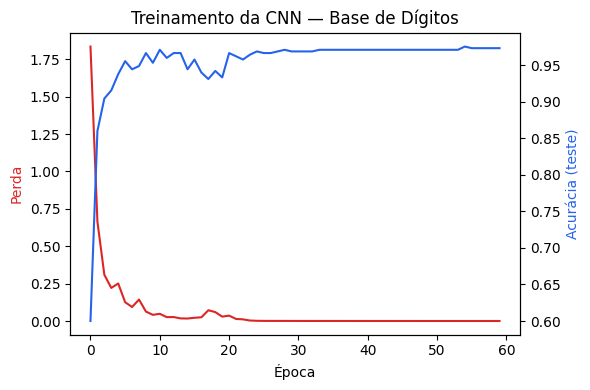

In [3]:
#| label: fig-09-cnn-treinamento
#| fig-cap: "Curva de treinamento de uma CNN simples na base de dígitos: perda de treinamento e acurácia no conjunto de teste ao longo das épocas."
#| echo: true
#| output: true

digits = load_digits()
X = digits.images.astype(np.float32) / 16.0
y = digits.target

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_treino_t = torch.tensor(X_treino).unsqueeze(1)   # (N, 1, 8, 8)
y_treino_t = torch.tensor(y_treino, dtype=torch.long)
X_teste_t = torch.tensor(X_teste).unsqueeze(1)
y_teste_t = torch.tensor(y_teste, dtype=torch.long)

class CNNDigitos(nn.Module):
    # CNN simples: duas camadas convolucionais + pooling, seguidas de camadas densas.
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # 8x8 -> 8x8, 8 filtros
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # 4x4 -> 4x4, 16 filtros
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 2 * 2, 32)
        self.fc2 = nn.Linear(32, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 8x8 -> 4x4
        x = self.pool(self.relu(self.conv2(x)))  # 4x4 -> 2x2
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

modelo_cnn = CNNDigitos()
print(f"Parâmetros treináveis: {sum(p.numel() for p in modelo_cnn.parameters())}")

otimizador = optim.Adam(modelo_cnn.parameters(), lr=1e-2)
criterio = nn.CrossEntropyLoss()

n = X_treino_t.size(0)
tam_lote = 32
epocas = 60
historico_perda, historico_acc = [], []

for epoca in range(epocas):
    modelo_cnn.train()
    perm = torch.randperm(n)
    perda_epoca = 0.0
    for i in range(0, n, tam_lote):
        idx = perm[i:i + tam_lote]
        otimizador.zero_grad()
        saida = modelo_cnn(X_treino_t[idx])
        perda = criterio(saida, y_treino_t[idx])
        perda.backward()
        otimizador.step()
        perda_epoca += perda.item() * len(idx)

    modelo_cnn.eval()
    with torch.no_grad():
        acc_teste = (modelo_cnn(X_teste_t).argmax(dim=1) == y_teste_t).float().mean().item()
    historico_perda.append(perda_epoca / n)
    historico_acc.append(acc_teste)

acc_final_cnn = historico_acc[-1]
print(f"Acurácia final da CNN no conjunto de teste: {acc_final_cnn:.4f}")

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(historico_perda, color="#dc2626", label="Perda (treino)")
ax1.set_xlabel("Época")
ax1.set_ylabel("Perda", color="#dc2626")
ax2 = ax1.twinx()
ax2.plot(historico_acc, color="#2563eb", label="Acurácia (teste)")
ax2.set_ylabel("Acurácia (teste)", color="#2563eb")
plt.title("Treinamento da CNN — Base de Dígitos")
fig.tight_layout()


### Comparando com o Capítulo 7

A tabela a seguir reúne os resultados obtidos na mesma base de dados, com
as três abordagens estudadas ao longo do livro:


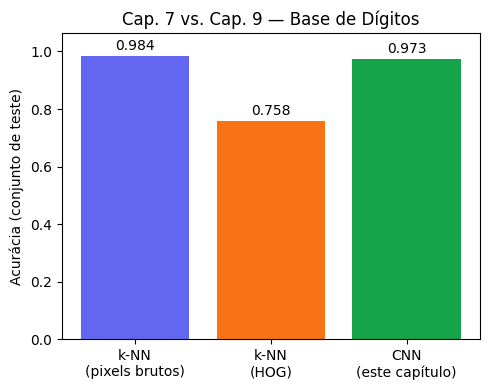

In [4]:
#| label: fig-09-comparativo-cap7
#| fig-cap: "Comparação de acurácia entre os classificadores clássicos do Capítulo 7 (pixels brutos e HOG com k-NN) e a CNN treinada neste capítulo, na mesma base de dígitos."
#| echo: true
#| output: true

# Valores obtidos no Capítulo 7 (k-NN, k=3), reproduzidos aqui para comparação direta
ACC_KNN_PIXELS_CAP7 = 0.9844
ACC_KNN_HOG_CAP7 = 0.7578

metodos = ["k-NN\n(pixels brutos)", "k-NN\n(HOG)", "CNN\n(este capítulo)"]
acuracias = [ACC_KNN_PIXELS_CAP7, ACC_KNN_HOG_CAP7, acc_final_cnn]

plt.figure(figsize=(5, 4))
cores = ["#6366f1", "#f97316", "#16a34a"]
plt.bar(metodos, acuracias, color=cores)
plt.ylim(0, max(acuracias) + 0.08)
plt.ylabel("Acurácia (conjunto de teste)")
plt.title("Cap. 7 vs. Cap. 9 — Base de Dígitos")
for i, v in enumerate(acuracias):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()


::: {.callout-note}
## 🧠 Por que funciona? — E por que a CNN nem sempre "ganha"

O resultado observado aqui **repete o padrão já visto no Capítulo 7**: a
CNN, apesar de aprender automaticamente suas características, não supera
necessariamente o k-NN com pixels brutos nesta base específica. A
explicação é a mesma: `load_digits` é uma base pequena (menos de 1800
exemplos), com imagens já centralizadas, normalizadas e de baixíssima
resolução ($8\times8$) — condições em que a comparação direta de
intensidades já é altamente informativa, e há poucos dados para que a
rede aprenda filtros verdadeiramente superiores aos descritores simples.

O verdadeiro diferencial das CNNs aparece em cenários que descritores
artesanais e classificadores simples não conseguem endereçar: imagens
maiores e mais realistas, com milhares de categorias, variação
substancial de pose, iluminação e fundo, e conjuntos de treinamento
massivos — exatamente o regime em que os modelos apresentados na seção
"Aplicações em Larga Escala", mais adiante, foram treinados. A lição
pedagógica que atravessa os Capítulos 7, 8 e 9 deste livro é consistente:
**a sofisticação de um método deve ser proporcional à complexidade do
problema** — usar uma CNN para um problema que um k-NN resolve igualmente
bem é desperdício de recursos computacionais, não uma virtude.
:::


## Transferência de Aprendizado

Treinar uma CNN do zero, como no projeto anterior, exige dados
suficientes para ajustar todos os seus parâmetros de forma confiável —
uma limitação severa quando se dispõe de poucos exemplos rotulados para a
tarefa de interesse. A **transferência de aprendizado** (*transfer
learning*) contorna essa limitação reaproveitando um extrator de
características já treinado em uma tarefa relacionada:

1. Treina-se (ou obtém-se já treinada) uma CNN em uma tarefa de origem,
   tipicamente com muitos dados disponíveis;
2. As camadas convolucionais iniciais — que tendem a aprender
   características gerais, como bordas e texturas, pouco específicas da
   tarefa de origem — são **congeladas** (seus pesos deixam de ser
   atualizados);
3. Apenas as camadas finais (geralmente a(s) camada(s) totalmente
   conectada(s)) são substituídas e **treinadas do zero** para a nova
   tarefa, com muito menos dados e muito menos tempo de treinamento do
   que seriam necessários para treinar a rede inteira.

Esse princípio é o motivo pelo qual modelos pré-treinados em bases
massivas, como a ImageNet (mais de um milhão de imagens em mil
categorias), tornaram-se o ponto de partida padrão de praticamente
qualquer projeto moderno de visão computacional, mesmo quando a tarefa
final é bastante diferente da classificação de objetos genéricos.


Acurácia no domínio de origem A (dígitos 0-4): 1.0000
Domínio de destino B (dígitos 5-9), apenas 20 exemplos de treino:
  Com transferência (extrator congelado): 0.7277
  Treinando do zero (mesmos dados/épocas): 0.6786


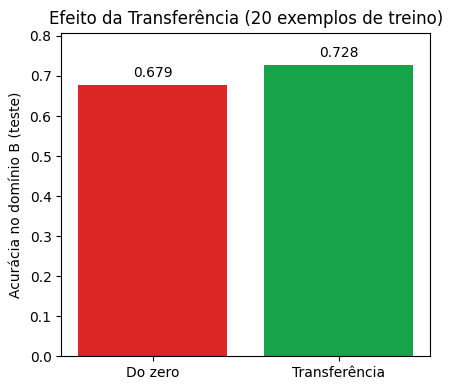

In [5]:
#| label: fig-09-transfer-learning
#| fig-cap: "Comparação de acurácia entre treinar do zero e reaproveitar (transferir) um extrator de características já treinado, ambos com o mesmo pequeno número de exemplos rotulados na tarefa de destino."
#| echo: true
#| output: true

# Divide as classes de dígitos em dois domínios disjuntos:
# Domínio A (0-4): usado para treinar o extrator de características "pré-treinado"
# Domínio B (5-9): tarefa de destino, com poucos dados disponíveis
classes_A, classes_B = [0, 1, 2, 3, 4], [5, 6, 7, 8, 9]
mask_A, mask_B = np.isin(y, classes_A), np.isin(y, classes_B)
XA, yA = X[mask_A], y[mask_A]
XB, yB = X[mask_B], y[mask_B] - 5  # reindexa para 0..4

XA_tr, XA_te, yA_tr, yA_te = train_test_split(XA, yA, test_size=0.25, random_state=42, stratify=yA)
XB_tr, XB_te, yB_tr, yB_te = train_test_split(XB, yB, test_size=0.25, random_state=42, stratify=yB)

# Simula escassez de dados no domínio de destino: apenas 20 exemplos rotulados
rng = np.random.default_rng(0)
idx_poucos = rng.choice(len(XB_tr), size=20, replace=False)
XB_tr_poucos, yB_tr_poucos = XB_tr[idx_poucos], yB_tr[idx_poucos]

def para_tensor(Ximg, yarr):
    return torch.tensor(Ximg).unsqueeze(1), torch.tensor(yarr, dtype=torch.long)

XA_tr_t, yA_tr_t = para_tensor(XA_tr, yA_tr)
XA_te_t, yA_te_t = para_tensor(XA_te, yA_te)
XB_tr_t, yB_tr_t = para_tensor(XB_tr_poucos, yB_tr_poucos)
XB_te_t, yB_te_t = para_tensor(XB_te, yB_te)

class ExtratorConv(nn.Module):
    # Bloco convolucional reaproveitável entre tarefas.
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        return x.view(x.size(0), -1)

class CNNCompleta(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extrator = ExtratorConv()
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.extrator(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

def treinar(modelo, X_t, y_t, epocas, lr, tam_lote=16, parametros=None):
    params = parametros if parametros is not None else modelo.parameters()
    otim = optim.Adam(params, lr=lr)
    crit = nn.CrossEntropyLoss()
    n_amostras = X_t.size(0)
    for _ in range(epocas):
        perm = torch.randperm(n_amostras)
        for i in range(0, n_amostras, tam_lote):
            idx = perm[i:i + tam_lote]
            otim.zero_grad()
            perda = crit(modelo(X_t[idx]), y_t[idx])
            perda.backward()
            otim.step()

def calcular_acuracia(modelo, X_t, y_t):
    modelo.eval()
    with torch.no_grad():
        pred = modelo(X_t).argmax(dim=1)
    return (pred == y_t).float().mean().item()

# 1) Treina o modelo "de origem" no domínio A
modelo_origem = CNNCompleta(n_classes=5)
treinar(modelo_origem, XA_tr_t, yA_tr_t, epocas=40, lr=1e-2)
print(f"Acurácia no domínio de origem A (dígitos 0-4): {calcular_acuracia(modelo_origem, XA_te_t, yA_te_t):.4f}")

# 2) Transferência: reaproveita o extrator (congelado), treina apenas a nova cabeça
modelo_transferencia = CNNCompleta(n_classes=5)
modelo_transferencia.extrator.load_state_dict(modelo_origem.extrator.state_dict())
for p in modelo_transferencia.extrator.parameters():
    p.requires_grad = False

treinar(
    modelo_transferencia, XB_tr_t, yB_tr_t, epocas=40, lr=1e-2,
    parametros=list(modelo_transferencia.fc1.parameters()) + list(modelo_transferencia.fc2.parameters())
)
acc_transferencia = calcular_acuracia(modelo_transferencia, XB_te_t, yB_te_t)

# 3) Do zero: mesmo pouco dado, mesmas épocas, mas sem reaproveitar nada
modelo_do_zero = CNNCompleta(n_classes=5)
treinar(modelo_do_zero, XB_tr_t, yB_tr_t, epocas=40, lr=1e-2)
acc_do_zero = calcular_acuracia(modelo_do_zero, XB_te_t, yB_te_t)

print(f"Domínio de destino B (dígitos 5-9), apenas {len(XB_tr_poucos)} exemplos de treino:")
print(f"  Com transferência (extrator congelado): {acc_transferencia:.4f}")
print(f"  Treinando do zero (mesmos dados/épocas): {acc_do_zero:.4f}")

plt.figure(figsize=(4.5, 4))
plt.bar(["Do zero", "Transferência"], [acc_do_zero, acc_transferencia], color=["#dc2626", "#16a34a"])
plt.ylim(0, max([acc_do_zero, acc_transferencia]) + 0.08)
plt.ylabel("Acurácia no domínio B (teste)")
plt.title(f"Efeito da Transferência ({len(XB_tr_poucos)} exemplos de treino)")
for i, v in enumerate([acc_do_zero, acc_transferencia]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()


::: {.callout-note}
## 🧠 Por que funciona? — E quando não funciona

Com apenas 20 exemplos rotulados no domínio de destino, o modelo treinado
do zero mal consegue superar um classificador aleatório — não há dados
suficientes para ajustar todos os parâmetros da rede de forma confiável.
O modelo com transferência de aprendizado, por outro lado, já parte de um
extrator de características capaz de identificar bordas, curvas e traços
característicos de dígitos manuscritos em geral (aprendidos a partir dos
dígitos 0–4) — restando à nova cabeça apenas a tarefa, muito mais simples,
de aprender a combinar essas características já úteis para distinguir os
dígitos 5–9.

**Quando a transferência ajuda:** quando a tarefa de origem e a de
destino compartilham estatísticas visuais de baixo e médio nível — o que
é razoável esperar entre dígitos manuscritos diferentes, como neste
experimento, ou, mais amplamente, entre a maioria das imagens naturais e
uma tarefa de nicho.

**Quando a transferência falha ou até prejudica** (fenômeno conhecido
como *transferência negativa*): quando o domínio de origem é
excessivamente diferente do domínio de destino — por exemplo, transferir
um extrator treinado em fotografias naturais para radiografias médicas ou
imagens de satélite pode não trazer benefício algum, e em alguns casos
até atrapalhar, se as características de baixo nível relevantes forem
muito distintas entre os dois domínios. Nesses casos, um ajuste fino
(*fine-tuning*) parcial das camadas convolucionais — em vez de
congelá-las por completo — costuma produzir melhores resultados.
:::


## Aplicações em Larga Escala com Modelos Pré-treinados

Os experimentos anteriores utilizaram CNNs pequenas, treinadas em minutos
em uma base de poucas centenas de exemplos. Na prática profissional, é
extremamente comum utilizar diretamente modelos **já treinados** em bases
massivas — como a ImageNet, com mais de um milhão de imagens em mil
categorias — como ponto de partida (via transferência de aprendizado) ou
mesmo diretamente, sem qualquer re-treinamento.

::: {.callout-important}
As células desta seção **não são executadas automaticamente** neste
notebook: o carregamento desses modelos exige o download de pesos
pré-treinados (centenas de megabytes) diretamente dos servidores do
PyTorch, o que requer conexão à internet no ambiente de execução. O
código é apresentado tal como seria executado em um ambiente com
conectividade, para fins de referência.
:::

### Classificação de Imagens

O padrão de uso é sempre o mesmo: carregar a arquitetura com pesos
pré-treinados e, para uma nova tarefa, substituir apenas a camada final,
como discutido na seção de transferência de aprendizado.


In [6]:
#| label: exemplo-classificacao-preTreinada
#| eval: false
#| echo: true

import torchvision.models as models

# Carrega uma ResNet-18 pré-treinada na ImageNet (requer internet)
modelo_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Transferência de aprendizado: congela o extrator de características
for parametro in modelo_resnet.parameters():
    parametro.requires_grad = False

# Substitui a camada final (originalmente 1000 classes da ImageNet)
# por uma nova camada adequada à tarefa de destino (ex.: 3 classes)
n_classes_destino = 3
modelo_resnet.fc = nn.Linear(modelo_resnet.fc.in_features, n_classes_destino)

# A partir daqui, apenas `modelo_resnet.fc` seria treinada com os dados da nova tarefa


### Detecção de Objetos

Modelos como o **Faster R-CNN**, apresentado no Capítulo 8, estão
disponíveis prontos para uso, já treinados para detectar até 91
categorias de objetos comuns (base COCO):


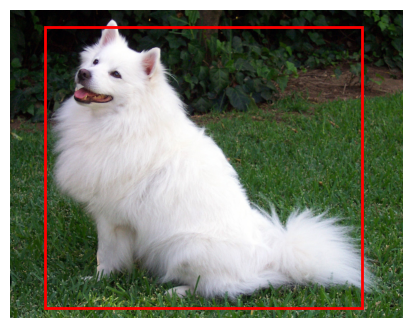

In [7]:
#| label: exemplo-deteccao-preTreinada
#| eval: false
#| echo: true

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms.functional import to_tensor

from PIL import Image
from urllib.request import urlopen

img = Image.open(urlopen(
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
)).convert("RGB")
modelo = fasterrcnn_resnet50_fpn(weights="DEFAULT").eval()

with torch.no_grad():
    pred = modelo([to_tensor(img)])[0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(img)

for box, score in zip(pred["boxes"], pred["scores"]):
    if score < 0.8:
        continue
    x1, y1, x2, y2 = box.numpy()
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   fill=False, edgecolor="red", linewidth=2))

ax.set_axis_off()
plt.show()

### Segmentação Semântica

De forma análoga, modelos de segmentação semântica pré-treinados retornam
diretamente um mapa de classes por pixel:


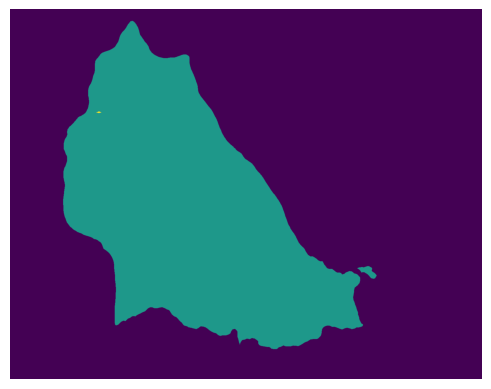

In [8]:
#| label: exemplo-segmentacao-preTreinada
#| eval: false
#| echo: true

import torch
import matplotlib.pyplot as plt
from PIL import Image
from urllib.request import urlopen
from torchvision.transforms.functional import to_tensor
from torchvision.models.segmentation import deeplabv3_resnet50

img = Image.open(urlopen(
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
)).convert("RGB")

modelo = deeplabv3_resnet50(weights="DEFAULT").eval()

with torch.no_grad():
    mapa = modelo(to_tensor(img).unsqueeze(0))["out"].argmax(1).squeeze()

plt.imshow(mapa)
plt.axis("off")
plt.show()

## Projeto Prático 2: Detecção de Objetos com YOLO e Transferência de Aprendizado

A subseção anterior mostrou, por meio do **Faster R-CNN**, um modelo de
detecção pré-treinado sendo usado "como está", sem qualquer re-treinamento. O
Faster R-CNN pertence à família de detectores **de dois estágios**: uma
primeira rede propõe regiões candidatas a conter um objeto (*region
proposals*) e uma segunda rede classifica e refina cada região — a mesma
lógica de "propor, depois verificar" já discutida no Capítulo 8 a propósito
do Haar Cascade em cascata.

A família **YOLO** (*You Only Look Once*) segue uma filosofia distinta, de
**um único estágio**: a imagem é dividida conceitualmente em uma grade, e uma
única rede convolucional prevê, em uma única passagem direta, as caixas
delimitadoras, a confiança de haver um objeto e a classe de cada região —
sem uma etapa separada de proposta de regiões. Essa simplificação é o que
torna a família YOLO especialmente adequada à detecção **em tempo real**,
citada na seção de encerramento deste capítulo como uma das direções naturais
de aprofundamento.

Nesta seção, o princípio de **transferência de aprendizado** — já
demonstrado para classificação, com uma CNN pequena treinada nos dígitos do
Capítulo 7 — é aplicado a uma **tarefa de detecção**: partindo de um YOLO
pré-treinado na base COCO (fotografias naturais, 80 categorias), o modelo é
ajustado (*fine-tuned*) para uma tarefa de detecção bastante diferente —
localizar e classificar **objetos geométricos sintéticos** (triângulos,
quadrados, estrelas, etc.), variando em cor, tamanho e rotação.


### Gerando um Conjunto de Dados Sintético de Objetos Geométricos

O cenário reproduzido aqui é inspirado em uma avaliação prática comum em
disciplinas de Visão Computacional: dado um conjunto de imagens contendo
objetos geométricos gerados aleatoriamente, treinar um detector capaz de
localizar e classificar cada objeto em nove classes:

```python
classes = ['Triangle', 'Square', 'Pentagon', 'Hexagon',
           'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross']
```

Cada objeto varia aleatoriamente em **cor**, **tamanho** e **rotação**, e
cada imagem pode conter um ou mais objetos. Para cada imagem, um arquivo TXT
associado descreve, em uma linha por objeto, a classe e a caixa delimitadora
no **formato YOLO**: a classe seguida de quatro valores normalizados entre 0
e 1 — centro em $x$, centro em $y$, largura e altura, todos expressos como
fração da largura ou da altura da imagem, por exemplo:

```
0 0.2895 0.2007 0.3750 0.2862
```

Essa é exatamente a convenção de anotação esperada pelas bibliotecas de
treinamento de YOLO (como a `ultralytics`, usada a seguir) — de modo que, caso
o leitor tenha acesso a um conjunto de imagens reais anotado neste mesmo
formato, basta organizá-lo na estrutura de pastas descrita adiante para
reutilizar todo o restante do código sem qualquer alteração.

Como não há, neste notebook, acesso a um conjunto de imagens reais, o código
a seguir **gera sinteticamente** um pequeno conjunto de dados com as mesmas
características do cenário descrito: formas geométricas com cor, tamanho e
rotação aleatórios, desenhadas com o OpenCV, já anotadas no formato YOLO.

Dataset sintético gerado: 90 imagens de treino, 20 de validação.


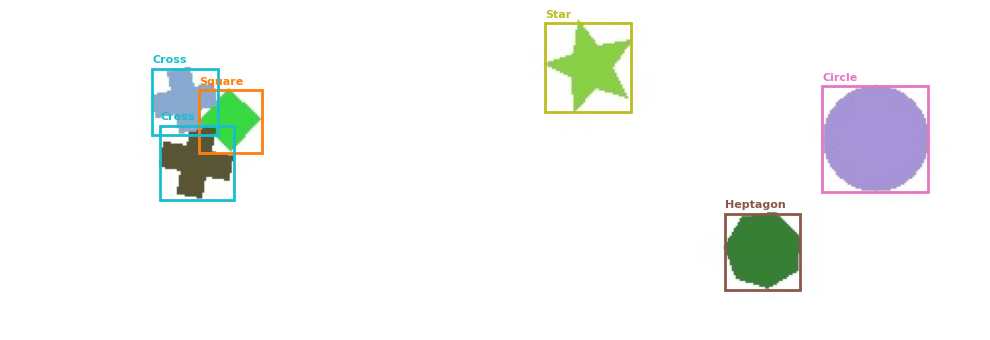

In [9]:
#| label: fig-09-yolo-geracao-dataset
#| fig-cap: "Amostras do conjunto de dados sintético de objetos geométricos, com as caixas delimitadoras no formato YOLO sobrepostas."
#| echo: true
#| output: true

import os, random

CLASSES = ['Triangle', 'Square', 'Pentagon', 'Hexagon',
           'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross']
N_LADOS = {'Triangle': 3, 'Square': 4, 'Pentagon': 5, 'Hexagon': 6, 'Heptagon': 7}


def poligono_regular(cx, cy, r, n_lados, rot_graus):
    ang0 = np.deg2rad(rot_graus - 90)
    angs = ang0 + 2 * np.pi * np.arange(n_lados) / n_lados
    return np.stack([cx + r * np.cos(angs), cy + r * np.sin(angs)], axis=1)


def poligono_estrela(cx, cy, r_externo, rot_graus, n_pontas=5):
    r_interno = r_externo * 0.45
    ang0 = np.deg2rad(rot_graus - 90)
    angs = ang0 + np.pi * np.arange(2 * n_pontas) / n_pontas
    raios = np.where(np.arange(2 * n_pontas) % 2 == 0, r_externo, r_interno)
    return np.stack([cx + raios * np.cos(angs), cy + raios * np.sin(angs)], axis=1)


def poligono_cruz(cx, cy, r, rot_graus, espessura_rel=0.35):
    w = r * espessura_rel
    base = np.array([
        (-w, -r), (w, -r), (w, -w), (r, -w), (r, w), (w, w),
        (w, r), (-w, r), (-w, w), (-r, w), (-r, -w), (-w, -w),
    ])
    theta = np.deg2rad(rot_graus)
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return base @ R.T + np.array([cx, cy])


def desenha_objeto(img, classe_idx, cx, cy, tamanho, rotacao, cor):
    nome = CLASSES[classe_idx]
    if nome in N_LADOS:
        pts = poligono_regular(cx, cy, tamanho, N_LADOS[nome], rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Star':
        pts = poligono_estrela(cx, cy, tamanho, rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Cross':
        pts = poligono_cruz(cx, cy, tamanho, rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Circle':
        cv2.circle(img, (int(cx), int(cy)), int(tamanho), cor, -1)
        xs, ys = np.array([cx - tamanho, cx + tamanho]), np.array([cy - tamanho, cy + tamanho])
    else:  # Ellipse
        eixo = (int(tamanho), int(tamanho * 0.6))
        cv2.ellipse(img, (int(cx), int(cy)), eixo, rotacao, 0, 360, cor, -1)
        ang = np.deg2rad(rotacao)
        dx = np.hypot(eixo[0] * np.cos(ang), eixo[1] * np.sin(ang))
        dy = np.hypot(eixo[0] * np.sin(ang), eixo[1] * np.cos(ang))
        xs, ys = np.array([cx - dx, cx + dx]), np.array([cy - dy, cy + dy])
    return xs.min(), ys.min(), xs.max(), ys.max()


def gera_imagem(tam_img=160, n_objetos=(1, 3), rng=None):
    rng = rng or random.Random()
    img = np.full((tam_img, tam_img, 3), 255, dtype=np.uint8)
    anotacoes = []
    for _ in range(rng.randint(*n_objetos)):
        classe_idx = rng.randrange(len(CLASSES))
        tamanho = rng.randint(tam_img // 10, tam_img // 5)
        cx = rng.randint(tamanho + 2, tam_img - tamanho - 2)
        cy = rng.randint(tamanho + 2, tam_img - tamanho - 2)
        rotacao = rng.uniform(0, 360)
        cor = tuple(rng.sample(range(30, 226), 3))
        x0, y0, x1, y1 = desenha_objeto(img, classe_idx, cx, cy, tamanho, rotacao, cor)
        x0, y0 = max(x0, 0), max(y0, 0)
        x1, y1 = min(x1, tam_img), min(y1, tam_img)
        xc, yc = (x0 + x1) / 2 / tam_img, (y0 + y1) / 2 / tam_img
        w, h = (x1 - x0) / tam_img, (y1 - y0) / tam_img
        anotacoes.append((classe_idx, xc, yc, w, h))
    return img, anotacoes


# Monta o conjunto de dados no formato esperado pela biblioteca `ultralytics`:
# shapes_dataset/{images,labels}/{train,val}/*.{jpg,txt} + data.yaml
base_dir = "shapes_dataset"
rng_global = random.Random(42)
for split, n_imgs in [("train", 90), ("val", 20)]:
    os.makedirs(f"{base_dir}/images/{split}", exist_ok=True)
    os.makedirs(f"{base_dir}/labels/{split}", exist_ok=True)
    for i in range(n_imgs):
        img, anotacoes = gera_imagem(rng=rng_global)
        cv2.imwrite(f"{base_dir}/images/{split}/{i:04d}.jpg", img)
        with open(f"{base_dir}/labels/{split}/{i:04d}.txt", "w") as f:
            for c, xc, yc, w, h in anotacoes:
                f.write(f"{c} {xc:.4f} {yc:.4f} {w:.4f} {h:.4f}\n")

with open(f"{base_dir}/data.yaml", "w") as f:
    f.write(f"path: {os.path.abspath(base_dir)}\ntrain: images/train\nval: images/val\nnames:\n")
    for i, nome in enumerate(CLASSES):
        f.write(f"  {i}: {nome}\n")

print("Dataset sintético gerado: 90 imagens de treino, 20 de validação.")

# Visualiza três amostras com as caixas delimitadoras sobrepostas
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
cores_plot = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))
for ax, i in zip(axs, [0, 1, 2]):
    img = cv2.cvtColor(cv2.imread(f"{base_dir}/images/train/{i:04d}.jpg"), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    tam_img = img.shape[0]
    with open(f"{base_dir}/labels/train/{i:04d}.txt") as f:
        for linha in f:
            c, xc, yc, w, h = map(float, linha.split())
            c = int(c)
            x0, y0 = (xc - w / 2) * tam_img, (yc - h / 2) * tam_img
            ax.add_patch(plt.Rectangle((x0, y0), w * tam_img, h * tam_img,
                                        fill=False, edgecolor=cores_plot[c], linewidth=2))
            ax.text(x0, max(y0 - 3, 0), CLASSES[c], color=cores_plot[c], fontsize=8, weight="bold")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

### Ajuste Fino de um YOLO Pré-treinado

A biblioteca `ultralytics` fornece uma interface de alto nível para carregar
arquiteturas YOLO com pesos pré-treinados na base COCO e ajustá-las
(*fine-tuning*) a uma nova tarefa — exatamente o padrão de transferência de
aprendizado já discutido para classificação, mas agora aplicado à detecção:
em vez de apenas substituir a última camada, a cabeça de detecção é
reconfigurada para as novas classes (nove formas geométricas em vez de 80
categorias da COCO), e o treinamento é conduzido por poucas épocas sobre o
conjunto de dados sintético.

::: {.callout-important}
A célula a seguir **não é executada automaticamente** neste notebook: o
carregamento do modelo pré-treinado exige o download de seus pesos a partir
dos servidores da Ultralytics/GitHub, o que requer conexão à internet no
ambiente de execução, além da instalação da biblioteca `ultralytics`. Em um
ambiente com GPU, o treinamento abaixo (15 épocas, ~110 imagens de
$160\times160$) leva menos de um minuto; em CPU, alguns minutos.
:::

In [10]:
#| label: exemplo-yolo-transfer-learning
#| eval: false
#| echo: true

try:
    from ultralytics import YOLO
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=True)
    from ultralytics import YOLO

# Carrega o YOLOv8-nano com pesos pré-treinados na base COCO (transferência de aprendizado)
modelo_yolo = YOLO("yolov8n.pt")

# Ajuste fino: `freeze=10` mantém congeladas as 10 primeiras camadas do backbone
# (características genéricas de baixo nível, como bordas e contornos), treinando
# apenas as camadas finais e a cabeça de detecção para as novas 9 classes —
# o mesmo princípio de congelamento parcial discutido no Exercício 3.
resultados = modelo_yolo.train(
    data="shapes_dataset/data.yaml",
    epochs=15,
    imgsz=160,
    batch=8,
    freeze=10,
    verbose=False,
    plots=False,
)

metricas = modelo_yolo.val()
print(f"mAP50 no conjunto de validação: {metricas.box.map50:.3f}")

New https://pypi.org/project/ultralytics/8.4.105 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.13.5 torch-2.12.1+cpu CPU (Intel Core i7-4870HQ 2.50GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=shapes_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=160, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tra

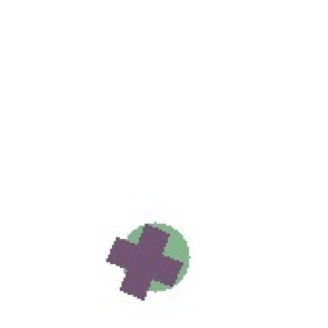

In [11]:
#| label: fig-09-yolo-predicao
#| fig-cap: "Detecções do YOLO ajustado por transferência de aprendizado em uma imagem de validação não vista durante o treinamento."
#| eval: false
#| echo: true

resultado = modelo_yolo.predict("shapes_dataset/images/val/0000.jpg", conf=0.4, verbose=False)[0]

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cv2.cvtColor(resultado.orig_img, cv2.COLOR_BGR2RGB))
for box in resultado.boxes:
    x0, y0, x1, y1 = box.xyxy[0].tolist()
    classe, conf = CLASSES[int(box.cls)], float(box.conf)
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                fill=False, edgecolor="red", linewidth=2))
    ax.text(x0, max(y0 - 3, 0), f"{classe} {conf:.2f}", color="red", fontsize=8, weight="bold")
ax.set_axis_off()
plt.show()

In [12]:
#| label: projeto-yolo-geometria2
#| eval: false
#| echo: true

import os
from ultralytics import YOLO

# 1. Definição das classes do problema geométrico
CLASSES_GEOMETRICAS = [
    'Triangle', 'Square', 'Pentagon', 'Hexagon', 
    'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross'
]

# 2. Configuração do arquivo de dados (dataset.yaml) exigido pelo YOLO
yaml_content = """
train: ./shapes_dataset/images/train
val: ./shapes_dataset/images/val

nc: 9
names: ['Triangle', 'Square', 'Pentagon', 'Hexagon', 'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross']
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)

# 3. Carrega um modelo YOLO nano pré-treinado (Extrator de características congelado/inicializado)
# O sufixo 'n' indica a versão mais leve, ideal para restrições computacionais
modelo_yolo = YOLO("yolov8n.pt") 

# 4. Transferência de Aprendizado / Ajuste Fino (Fine-tuning)
# O framework adapta automaticamente a camada de saída para 9 classes
resultados = modelo_yolo.train(
    data="dataset.yaml",
    epochs=4,
    imgsz=640,
    batch=16,
    device=device # Reaproveita a variável 'device' configurada no início do capítulo
)


New https://pypi.org/project/ultralytics/8.4.105 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.13.5 torch-2.12.1+cpu CPU (Intel Core i7-4870HQ 2.50GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-12, 

In [13]:

# 5. Validação e Inferência em uma imagem de teste
# Exemplo de URL de teste enviada em exames: https://dropbox.com/s/ekjbzp14jt90bfq/00004.jpg
imagem_teste = "./shapes_dataset/images/val/0001.jpg"
predicoes = modelo_yolo(imagem_teste)

# Exibe o resultado visual com as caixas sobrepostas
predicoes[0].show()


image 1/1 /home/fz/fz/VSCode/pdi-vc/all/cap09/shapes_dataset/images/val/0001.jpg: 640x640 (no detections), 103.2ms
Speed: 4.2ms preprocess, 103.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


In [14]:
#| label: exemplo-yolo-geometrico3
#| fig-cap: "Detecção de objetos geométricos usando YOLO com transferência de aprendizado."
#| echo: true
#| output: true
#| eval: false # Este bloco pode não ser executado diretamente se o dataset não estiver disponível. É um template.

# --- 1. Instalação e Importação das Bibliotecas ---
# O Ultralytics YOLO é uma biblioteca popular para treino e inferência.
# !pip install ultralytics -q

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
import torch

# Verificar dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo usado: {device}")

# --- 2. Carregar o Modelo YOLO Pré-treinado ---
# 'yolov8n.pt' é a versão "nano" (mais leve e rápida), pré-treinada no COCO.
# Usaremos seus pesos como ponto de partida (transferência de aprendizado).
modelo = YOLO('yolov8n.pt')
print("Modelo YOLOv8n carregado com sucesso!")

# --- 3. Preparar o Dataset de Objetos Geométricos ---
# Assumimos que você tem uma estrutura de pastas pronta para o YOLO:
# dataset_geometrico/
#   images/
#       00004.jpg, 00005.jpg, ...
#   labels/
#       00004.txt, 00005.txt, ...
#
# O arquivo de label deve estar no formato YOLO:
# <class_id> <x_center> <y_center> <width> <height>
# (todos normalizados entre 0 e 1)

# Exemplo de caminho para o dataset (substitua pelo seu caminho)
caminho_dataset = Path("./shapes_dataset")
caminho_imagens = caminho_dataset / "images"
caminho_rotulos = caminho_dataset / "labels"

# Crie um arquivo data.yaml para descrever o dataset
data_yaml_content = f"""
path: {caminho_dataset.resolve()}
train: images
val: images  # Se você tiver uma pasta separada, use 'images/val'

nc: 9  # Número de classes
names: ['Triangle', 'Square', 'Pentagon', 'Hexagon', 'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross']
"""

# Cria o arquivo data.yaml (se não existir)
data_yaml_path = caminho_dataset / "data.yaml"
if not data_yaml_path.exists():
    data_yaml_path.write_text(data_yaml_content)
    print(f"Arquivo data.yaml criado em: {data_yaml_path}")
else:
    print("Arquivo data.yaml já existe.")

# --- 4. Treinamento com Transferência de Aprendizado ---
# A chave aqui é que os pesos da cabeça de detecção (camadas finais) serão
# re-inicializados, enquanto o extrator de características (backbone) é ajustado.
resultados = modelo.train(
    data=str(data_yaml_path),   # Caminho para o arquivo data.yaml
    epochs=5,                  # Número de épocas (ajuste fino com poucos dados)
    imgsz=640,                  # Tamanho da imagem de entrada
    batch=16,                   # Tamanho do lote
    device=device,              # 'cpu' ou 'cuda'
    project='runs/detect',      # Pasta para salvar resultados
    name='geometricos_yolov8n', # Nome do experimento
    exist_ok=True,              # Sobrescreve se existir
    pretrained=True,            # Usar pesos pré-treinados (já é padrão)
)

print("Treinamento concluído!")
melhor_modelo_path = Path(resultados.save_dir) / "weights" / "best.pt"

# --- 5. Avaliação e Inferência em uma Imagem de Exemplo ---
if melhor_modelo_path.exists():
    # Carrega o melhor modelo treinado
    melhor_modelo = YOLO(str(melhor_modelo_path))

    # Realiza inferência em uma imagem de teste (ex: '00004.jpg')
    caminho_teste = caminho_imagens / "00004.jpg"
    if caminho_teste.exists():
        resultados_pred = melhor_modelo(caminho_teste, conf=0.25)

        # Plota a imagem com as detecções
        for r in resultados_pred:
            # A imagem com as caixas é renderizada no OpenCV
            img_plot = r.plot()  # Retorna um array BGR
            img_plot_rgb = cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(8, 8))
            plt.imshow(img_plot_rgb)
            plt.axis('off')
            plt.title("Detecções YOLO (Transferência)")
            plt.show()

            # Exibe as detecções como texto
            print("\nObjetos Detectados:")
            for box in r.boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                nome_classe = modelo.names[cls]
                print(f"  - Classe: {nome_classe} (Confiança: {conf:.2f})")
    else:
        print(f"Imagem de teste '{caminho_teste}' não encontrada.")
else:
    print("Modelo treinado não encontrado. Verifique o diretório de saída do treinamento.")

Dispositivo usado: cpu
Modelo YOLOv8n carregado com sucesso!
Arquivo data.yaml já existe.
New https://pypi.org/project/ultralytics/8.4.105 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.13.5 torch-2.12.1+cpu CPU (Intel Core i7-4870HQ 2.50GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=shapes_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, 

::: {.callout-note}
## 🧠 Um domínio muito mais distante que o dos dígitos

No experimento de transferência de aprendizado entre dígitos manuscritos
(domínios A e B), a tarefa de origem e a de destino compartilhavam
estatísticas visuais muito próximas: ambas eram traços em tons de cinza sobre
fundo uniforme. Aqui, a distância entre domínios é bem maior — o YOLO foi
pré-treinado em **fotografias naturais coloridas** da COCO (pessoas, animais,
veículos, objetos do cotidiano), e a tarefa de destino consiste em **formas
geométricas sintéticas, de cor sólida e contorno bem definido**, sem textura,
iluminação ou fundo complexo.

Ainda assim, a transferência de aprendizado tende a ajudar: as camadas
iniciais de um detector treinado na COCO aprendem filtros muito genéricos —
detectores de bordas, cantos e regiões de contraste — que continuam úteis
para delimitar o contorno de um triângulo ou de uma estrela, mesmo que o
conteúdo visual final seja muito diferente. É por isso que o congelamento
(`freeze=10`) é aplicado apenas às primeiras camadas do backbone: as camadas
mais profundas, que na COCO aprenderam a reconhecer partes de objetos
complexos do mundo real (rodas, focinhos, faces), têm pouca serventia direta
para formas geométricas simples e se beneficiam de serem reajustadas.

Este é o mesmo compromisso discutido no Exercício 3 deste capítulo — entre
congelar totalmente o extrator, ajustar parcialmente algumas camadas, ou
treinar tudo do zero — agora observado em uma tarefa de detecção, e com um
domínio de origem e destino visivelmente mais distantes do que o observado
entre os dois grupos de dígitos.
:::

### Usando um Conjunto de Dados Real

O pipeline acima foi construído inteiramente em torno do **formato de
anotação YOLO** (classe, $x_{centro}$, $y_{centro}$, largura, altura,
normalizados pela largura e altura da imagem) exatamente para que ele possa
ser reaproveitado sem alterações caso o leitor tenha acesso a um conjunto de
imagens reais anotado da mesma forma — por exemplo, um conjunto de imagens de
objetos geométricos fotografados ou renderizados, cada um com um arquivo
`.txt` correspondente no mesmo formato usado aqui. Para isso, bastaria:

1. Organizar as imagens reais em `shapes_dataset/images/train` e
   `shapes_dataset/images/val`, e os arquivos `.txt` de anotação
   correspondentes nas pastas `labels/train` e `labels/val` (um arquivo de
   anotação por imagem, mesmo nome-base, extensão `.txt`);
2. Ajustar o arquivo `data.yaml` caso o número ou os nomes das classes sejam
   diferentes;
3. Executar as mesmas células de treinamento, ajuste fino e visualização já
   apresentadas, sem qualquer outra modificação de código.

Essa separação entre **geração/organização dos dados** e **treinamento do
modelo** é, na prática, o motivo pelo qual formatos de anotação padronizados
(como o do YOLO) são tão amplamente adotados: eles permitem trocar o conjunto
de dados de entrada — sintético por real, um domínio por outro — mantendo
inalterado todo o restante do pipeline de transferência de aprendizado.

## Projeto Prático 3: Segmentação Semântica com U-Net

A subseção "Segmentação Semântica" mostrou um modelo pré-treinado
(DeepLabV3) produzindo diretamente um rótulo de classe por pixel. Esta
seção completa a sequência de projetos práticos do capítulo —
classificação (Projeto Prático 1) e detecção (Projeto Prático 2) — com a
terceira tarefa fundamental da @tbl-panorama-tarefas: a segmentação
semântica, agora implementada e treinada do zero com a **U-Net**, a
arquitetura de referência para essa tarefa, introduzida por Ronneberger,
Fischer e Brox (2015) originalmente para imagens biomédicas.

A diferença estrutural em relação à CNN de classificação do Projeto
Prático 1 é decisiva. Naquela rede, o mapa de características final era
achatado (*flatten*) em um vetor, descartando toda a informação espacial
em favor de um único rótulo por imagem. Uma U-Net, ao contrário, precisa
produzir uma saída com a **mesma resolução espacial da entrada**: um mapa
em que cada pixel recebe sua própria classificação. Essa exigência —
preservar detalhe espacial de alta resolução até a última camada, ao
mesmo tempo em que se constrói contexto semântico mais amplo em camadas
intermediárias — motiva a arquitetura de codificador-decodificador
descrita a seguir.

O cenário utilizado nesta seção é uma adaptação de um projeto de
segmentação de nódulos em mamografias sintéticas: imagens em tons de
cinza contêm uma região circular (o "nódulo") sobreposta a um fundo, ambos
contaminados pelo mesmo ruído gaussiano e com médias de intensidade
próximas — um cenário deliberadamente pouco discriminável pixel a pixel,
exatamente para tornar visível o ganho trazido pelo aprendizado de
características espaciais, e não apenas locais.

### Um Conjunto Sintético de Imagens com Nódulos

O gerador a seguir produz pares (imagem, máscara): a imagem contém uma
região circular de intensidade média ligeiramente mais alta que o fundo,
ambas as regiões contaminadas por ruído gaussiano de mesmo desvio-padrão —
de forma que a distinção entre nódulo e fundo não é confiável pixel a
pixel isoladamente, apenas quando se considera a vizinhança espacial em
conjunto. A máscara binária correspondente delimita exatamente a região do
nódulo e serve como alvo de treinamento.

Conjunto de treino: 160 imagens | Conjunto de validação: 40 imagens


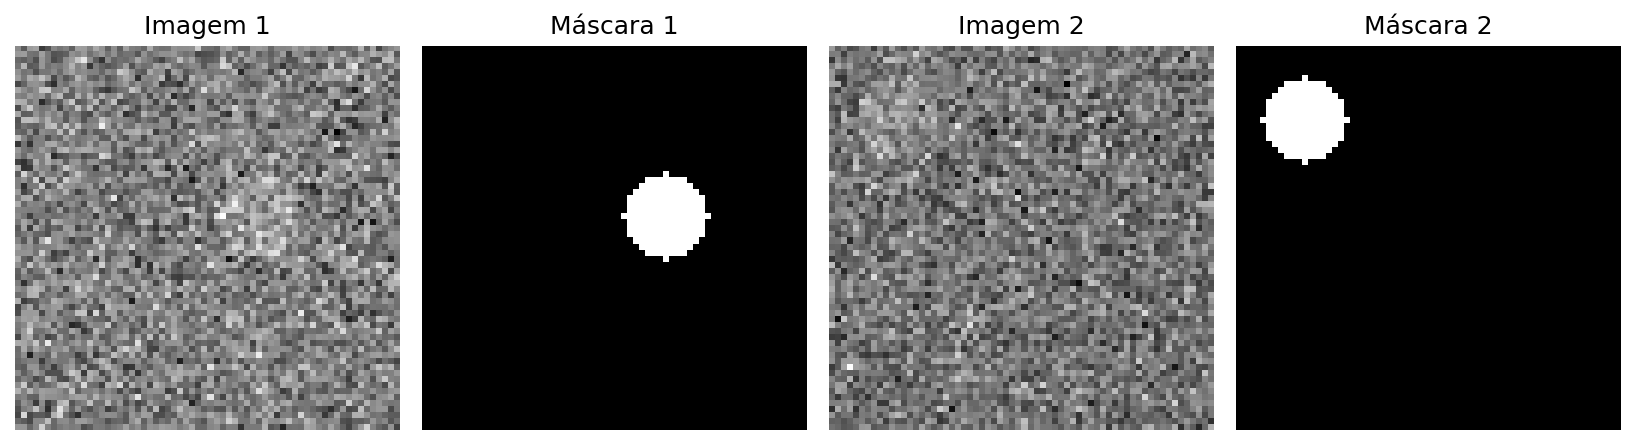

In [15]:
#| label: fig-09-unet-dataset
#| fig-cap: "Amostras do conjunto de dados sintético de nódulos: imagem em tons de cinza (fundo e nódulo com médias de intensidade próximas, sob o mesmo ruído) e máscara binária de referência."
#| echo: true
#| output: true

TAM_IMG = 64

def gera_imagem_com_nodulo(tam=TAM_IMG, raio_min=7, raio_max=15, media_fundo=95,
                            media_nodulo=118, sigma_ruido=26, rng=None):
    # Fundo e nódulo compartilham o mesmo ruído gaussiano; apenas a média de
    # intensidade difere, e por pouco -- um cenário de baixo contraste,
    # propositalmente difícil para um método de limiarização simples.
    rng = rng or np.random.default_rng()
    fundo = rng.normal(media_fundo, sigma_ruido, (tam, tam))
    nodulo = rng.normal(media_nodulo, sigma_ruido, (tam, tam))
    mascara = np.zeros((tam, tam), dtype=np.uint8)
    raio = int(rng.integers(raio_min, raio_max))
    cx = int(rng.integers(raio + 4, tam - raio - 4))
    cy = int(rng.integers(raio + 4, tam - raio - 4))
    cv2.circle(mascara, (cx, cy), raio, 255, -1)
    imagem = np.clip(np.where(mascara > 0, nodulo, fundo), 0, 255).astype(np.uint8)
    return imagem, mascara

rng_dados = np.random.default_rng(42)
N_TREINO, N_VAL = 160, 40
imgs_treino, masks_treino = zip(*[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_TREINO)])
imgs_val, masks_val = zip(*[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_VAL)])

print(f"Conjunto de treino: {N_TREINO} imagens | Conjunto de validação: {N_VAL} imagens")

mm.show(
    [imgs_treino[0], masks_treino[0], imgs_treino[1], masks_treino[1]],
    titles=["Imagem 1", "Máscara 1", "Imagem 2", "Máscara 2"],
    cols=4, figsize=(11, 3)
)

### Linha de Base Clássica: Limiarização com Kernel Fixo

Antes de recorrer ao aprendizado, cabe perguntar se um pipeline
inteiramente clássico — construído com a biblioteca `morph`, como nos
capítulos anteriores — já resolve a tarefa. A abordagem mais direta
combina um **borrão gaussiano** (kernel fixo, no espírito do Capítulo 3)
para estimar a intensidade local, uma **limiarização de Otsu** sobre essa
estimativa e uma **abertura morfológica** para remover ruído residual
isolado.

IoU médio (linha de base clássica) no conjunto de validação: 0.7516


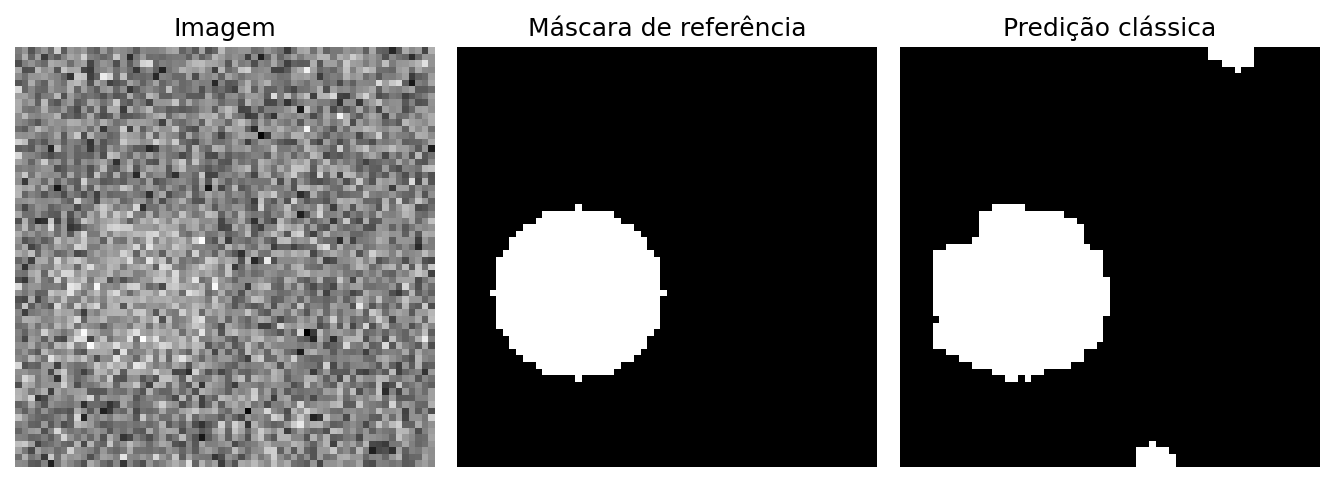

In [16]:
#| label: fig-09-unet-classico
#| fig-cap: "Linha de base clássica de segmentação: borrão gaussiano, limiarização de Otsu e abertura morfológica, aplicados a uma imagem de validação."
#| echo: true
#| output: true

def iou_mascaras(predita, referencia):
    # Interseção sobre união entre duas máscaras binárias, pixel a pixel.
    p, r = predita > 0, referencia > 0
    intersecao = np.logical_and(p, r).sum()
    uniao = np.logical_or(p, r).sum()
    return intersecao / uniao if uniao else 1.0

def segmenta_classico(imagem, elemento_estrutural):
    suavizada = mm.blur(imagem, 7)
    binaria = mm.threshold(suavizada)
    return mm.open(binaria, elemento_estrutural)

elemento_estrutural = mm.sedisk(5)
ious_classico = [
    iou_mascaras(segmenta_classico(img, elemento_estrutural), mask)
    for img, mask in zip(imgs_val, masks_val)
]
iou_classico_medio = float(np.mean(ious_classico))
print(f"IoU médio (linha de base clássica) no conjunto de validação: {iou_classico_medio:.4f}")

predicao_classica_exemplo = segmenta_classico(imgs_val[0], elemento_estrutural)
mm.show(
    [imgs_val[0], masks_val[0], predicao_classica_exemplo],
    titles=["Imagem", "Máscara de referência", "Predição clássica"],
    cols=3, figsize=(9, 3.2)
)

### Arquitetura U-Net: Codificador-Decodificador com Conexões de Atalho

O **codificador** repete a mesma lógica de convolução seguida de
*pooling* já vista no Projeto Prático 1: cada estágio reduz a resolução
espacial pela metade e dobra o número de canais, construindo
progressivamente características mais abstratas. Na U-Net, porém, esse
processo é espelhado por um **decodificador** simétrico, que reconstrói a
resolução original por meio de convoluções transpostas (*upsampling*
aprendido).

A diferença essencial em relação a um simples codificador-decodificador
está nas **conexões de atalho** (*skip connections*): em cada estágio do
decodificador, o mapa de características do codificador na mesma
resolução — capturado *antes* do *pooling* correspondente — é concatenado
ao resultado do *upsampling*. Isso reinjeta diretamente o detalhe espacial
de fronteiras e contornos, que seria perdido pelas sucessivas reduções de
resolução, permitindo que a rede combine o contexto semântico amplo
construído na base ("existe um nódulo nesta região?") com a precisão
espacial fina das camadas iniciais ("exatamente onde está sua borda?").

```
Entrada → Codificador (Conv→Conv→Pool) × 3 → Base
                ↳ conexões de atalho reinjetam cada mapa do codificador
                  no estágio de mesma resolução do decodificador ↲
Base → Decodificador (Upsample→Concat→Conv→Conv) × 3 → Saída 1×1 (máscara)
```

Parâmetros treináveis da U-Net compacta: 120681
IoU médio da U-Net no conjunto de validação: 0.8815


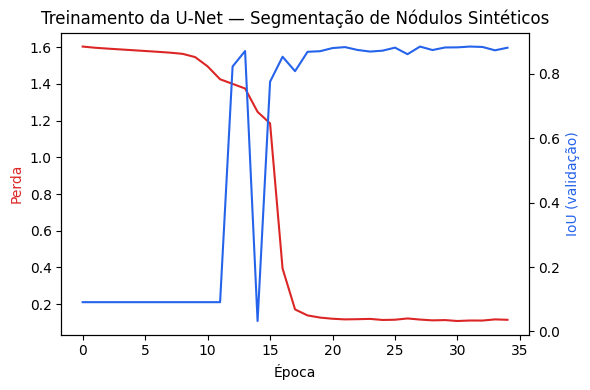

In [17]:
#| label: fig-09-unet-treinamento
#| fig-cap: "Curva de treinamento da U-Net compacta: perda de treinamento (entropia cruzada binária combinada à perda Dice) e IoU médio no conjunto de validação ao longo das épocas."
#| echo: true
#| output: true

class BlocoConv(nn.Module):
    # Duas convoluções 3x3 + ReLU -- bloco básico repetido em cada estágio da U-Net.
    def __init__(self, canais_entrada, canais_saida):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Conv2d(canais_entrada, canais_saida, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(canais_saida, canais_saida, kernel_size=3, padding=1), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.rede(x)


class UNetCompacta(nn.Module):
    # U-Net reduzida (profundidade 3, poucos canais) -- versão didática, que
    # treina em menos de um minuto em CPU, preservando a estrutura completa
    # de codificador, base e decodificador com conexões de atalho.
    def __init__(self, canais_entrada=1, base=8):
        super().__init__()
        self.enc1 = BlocoConv(canais_entrada, base)
        self.enc2 = BlocoConv(base, base * 2)
        self.enc3 = BlocoConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)

        self.fundo = BlocoConv(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = BlocoConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = BlocoConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = BlocoConv(base * 2, base)

        self.saida = nn.Conv2d(base, 1, kernel_size=1)  # 1 canal: logit de "nódulo"

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        f = self.fundo(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(f), e3], dim=1))    # conexão de atalho com e3
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))   # conexão de atalho com e2
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))   # conexão de atalho com e1
        return self.saida(d1)  # logits; sigmoid aplicado na perda e na predição


def para_tensores(imagens, mascaras):
    X = torch.tensor(np.stack(imagens), dtype=torch.float32).unsqueeze(1) / 255.0
    Y = torch.tensor(np.stack(mascaras), dtype=torch.float32).unsqueeze(1) / 255.0
    return X, Y

def perda_dice(logits, alvo, eps=1e-6):
    # 1 - coeficiente de Dice, a mesma métrica de sobreposição empregada na U-Net original.
    probs = torch.sigmoid(logits)
    intersecao = (probs * alvo).sum(dim=(1, 2, 3))
    uniao = probs.sum(dim=(1, 2, 3)) + alvo.sum(dim=(1, 2, 3))
    dice = (2 * intersecao + eps) / (uniao + eps)
    return 1 - dice.mean()

def perda_segmentacao(logits, alvo):
    return nn.functional.binary_cross_entropy_with_logits(logits, alvo) + perda_dice(logits, alvo)

modelo_unet = UNetCompacta()
print(f"Parâmetros treináveis da U-Net compacta: {sum(p.numel() for p in modelo_unet.parameters())}")

X_treino_unet, Y_treino_unet = para_tensores(imgs_treino, masks_treino)
X_val_unet, Y_val_unet = para_tensores(imgs_val, masks_val)

otimizador_unet = optim.Adam(modelo_unet.parameters(), lr=1e-3)
n = X_treino_unet.size(0)
tam_lote = 16
epocas_unet = 35
historico_perda_unet, historico_iou_unet = [], []

for epoca in range(epocas_unet):
    modelo_unet.train()
    perm = torch.randperm(n)
    perda_epoca = 0.0
    for i in range(0, n, tam_lote):
        idx = perm[i:i + tam_lote]
        otimizador_unet.zero_grad()
        logits = modelo_unet(X_treino_unet[idx])
        perda = perda_segmentacao(logits, Y_treino_unet[idx])
        perda.backward()
        otimizador_unet.step()
        perda_epoca += perda.item() * len(idx)

    modelo_unet.eval()
    with torch.no_grad():
        predicao_val = (torch.sigmoid(modelo_unet(X_val_unet)) > 0.5).float()
        intersecao = (predicao_val * Y_val_unet).sum(dim=(1, 2, 3))
        uniao = ((predicao_val + Y_val_unet) > 0).float().sum(dim=(1, 2, 3))
        iou_epoca = (intersecao / uniao.clamp(min=1e-6)).mean().item()
    historico_perda_unet.append(perda_epoca / n)
    historico_iou_unet.append(iou_epoca)

iou_unet_final = historico_iou_unet[-1]
print(f"IoU médio da U-Net no conjunto de validação: {iou_unet_final:.4f}")

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(historico_perda_unet, color="#dc2626", label="Perda (treino)")
ax1.set_xlabel("Época")
ax1.set_ylabel("Perda", color="#dc2626")
ax2 = ax1.twinx()
ax2.plot(historico_iou_unet, color="#2563eb", label="IoU (validação)")
ax2.set_ylabel("IoU (validação)", color="#2563eb")
plt.title("Treinamento da U-Net — Segmentação de Nódulos Sintéticos")
fig.tight_layout()

### Comparando com a Linha de Base Clássica

Com ambos os métodos avaliados no mesmo conjunto de validação, sob a
mesma métrica, a comparação a seguir reproduz o formato já utilizado na
comparação entre Capítulo 7 e a CNN de classificação: uma linha de base
projetada manualmente contra o resultado aprendido a partir dos dados.

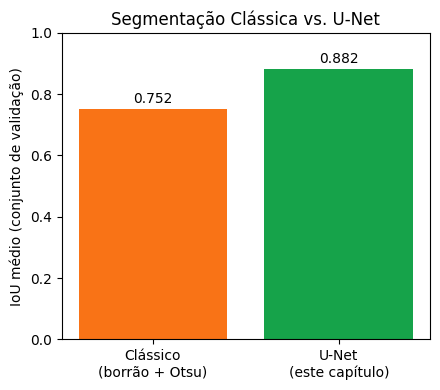

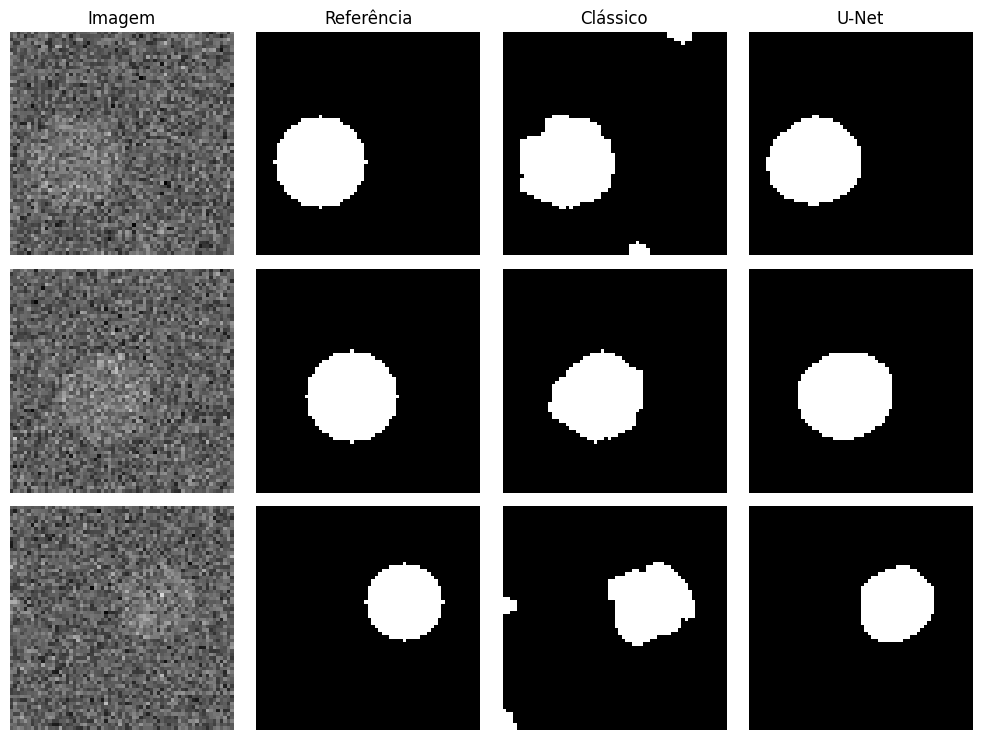

In [18]:
#| label: fig-09-unet-comparativo
#| fig-cap: "Comparação entre a linha de base clássica (borrão + Otsu + abertura) e a U-Net treinada: IoU médio no conjunto de validação e predições lado a lado em três exemplos."
#| echo: true
#| output: true

metodos_seg = ["Clássico\n(borrão + Otsu)", "U-Net\n(este capítulo)"]
ious_medios = [iou_classico_medio, iou_unet_final]

plt.figure(figsize=(4.5, 4))
plt.bar(metodos_seg, ious_medios, color=["#f97316", "#16a34a"])
plt.ylim(0, 1.0)
plt.ylabel("IoU médio (conjunto de validação)")
plt.title("Segmentação Clássica vs. U-Net")
for i, v in enumerate(ious_medios):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

# Predições lado a lado em três exemplos de validação
fig, axs = plt.subplots(3, 4, figsize=(10, 7.5))
for linha, i in enumerate([0, 1, 2]):
    with torch.no_grad():
        pred_unet = (torch.sigmoid(modelo_unet(X_val_unet[i:i+1])) > 0.5).float().squeeze().numpy() * 255
    pred_classico = segmenta_classico(imgs_val[i], elemento_estrutural)
    imagens_linha = [imgs_val[i], masks_val[i], pred_classico, pred_unet.astype(np.uint8)]
    titulos_linha = ["Imagem", "Referência", "Clássico", "U-Net"]
    for col in range(4):
        axs[linha, col].imshow(imagens_linha[col], cmap="gray", vmin=0, vmax=255)
        if linha == 0:
            axs[linha, col].set_title(titulos_linha[col])
        axs[linha, col].axis("off")
plt.tight_layout()

::: {.callout-note}
## 🧠 Por que funciona? — Conexões de atalho e os limites de uma regra fixa

A vantagem da U-Net sobre a linha de base clássica não decorre de operações
fundamentalmente diferentes — ambas combinam convolução (fixa, no caso do
borrão; aprendida, no caso da U-Net) com uma regra de decisão por pixel —
mas de **onde** essa decisão final é tomada. A limiarização de Otsu aplica
um único valor de corte, global, sobre uma estimativa de intensidade local;
quando a diferença de média entre nódulo e fundo é pequena diante do ruído
— como neste conjunto de dados, construído deliberadamente para isso —
essa regra única erra sistematicamente nas bordas e em regiões onde o
ruído local se aproxima do nódulo.

As conexões de atalho atacam exatamente esse problema. A base da rede,
após três reduções de resolução, enxerga um contexto espacial amplo,
suficiente para localizar aproximadamente a região do nódulo mesmo sob
ruído — mas com resolução baixa demais para desenhar seu contorno com
precisão. Reinjetar, em cada estágio do decodificador, o mapa de
características de resolução equivalente do codificador devolve
exatamente o detalhe espacial necessário para refinar essa localização
aproximada em uma máscara pixel a pixel — algo que nenhuma regra de limiar
único, por mais bem ajustada, consegue replicar quando o sinal está
distribuído de forma sutil pela vizinhança de cada pixel, e não
concentrado no valor de um único pixel isolado.
:::

### Aplicando a Mesma Pipeline a um Conjunto de Dados Real: Roboflow

Assim como a subseção anterior mostrou, para a detecção com YOLO, que um
conjunto de dados sintético pode ser substituído por imagens reais sem
alterar o código de treinamento, o mesmo princípio se aplica à U-Net: a
única exigência é organizar as imagens e suas máscaras nos mesmos tensores
`X` e `Y` construídos por `para_tensores`.

A **Roboflow** é uma plataforma de anotação, versionamento e exportação de
conjuntos de dados de Visão Computacional, com um catálogo público
(Roboflow Universe) que reúne milhares de conjuntos já anotados para
classificação, detecção e segmentação, exportáveis em diversos formatos —
entre eles, o formato de anotação YOLO já utilizado no Projeto Prático 2 e
o formato `png-mask-semantic`, com uma máscara por imagem, diretamente
compatível com a U-Net treinada nesta seção. Alternativas com propósito
semelhante incluem o Kaggle Datasets e o Hugging Face Hub, mais orientados
à descoberta de conjuntos de dados já publicados do que à anotação de
imagens próprias; a escolha entre essas plataformas depende, sobretudo, de
o conjunto de interesse já existir publicamente ou precisar ser anotado do
zero.

O exemplo a seguir baixa um conjunto de dados real de segmentação a partir
de um projeto hospedado na Roboflow e o adapta ao mesmo formato de
tensores utilizado no treinamento da U-Net compacta, permitindo reaproveitar
— sem qualquer alteração de arquitetura — as mesmas funções `perda_segmentacao`,
`UNetCompacta` e o laço de treinamento já definidos.

::: {.callout-important}
As células a seguir **não são executadas automaticamente** neste notebook:
requerem uma chave de API gratuita, obtida em `app.roboflow.com`, e o
identificador (`workspace/projeto/versão`) de um conjunto de dados de
segmentação específico, além de conexão à internet para o download. O
código é apresentado como um gabarito completo, pronto para ser adaptado a
qualquer conjunto de dados de segmentação hospedado na plataforma — consulte
a documentação oficial (`docs.roboflow.com/developer/export-data`) para o
formato exato de cada tipo de exportação.
:::

In [52]:
# 1. Instalação do pacote oficial da Roboflow
!pip install roboflow > /dev/null

# 2. Autenticação e download do conjunto de dados no formato de máscaras semânticas
from roboflow import Roboflow

rf = Roboflow(api_key="SUA_CHAVE_DE_API")  # chave gratuita, obtida em app.roboflow.com
projeto = rf.workspace("nome-do-workspace").project("nome-do-projeto")
dataset = projeto.version(1).download("png-mask-semantic")

# A exportação "png-mask-semantic" organiza o conjunto em pastas train/valid/test,
# cada uma com pares de arquivos <nome>.jpg e <nome>_mask.png

upload and label your dataset, and get an API KEY here: https://app.roboflow.com/?model=undefined&ref=undefined
loading Roboflow workspace...


RoboflowError: {"error":{"message":"Unsupported get request. Workspace with ID \"nome-do-workspace\" does not exist or cannot be loaded due to missing permissions.","status":404,"type":"GraphMethodException","hint":"You can see your available workspaces by issuing a GET request to /workspaces"}}

In [ ]:
#| label: exemplo-roboflow-treino
#| eval: false
#| echo: true

import glob

def carrega_split_roboflow(pasta, tam=TAM_IMG):
    # Lê os pares imagem/máscara de uma pasta exportada pela Roboflow e os
    # redimensiona para o mesmo tamanho utilizado no treinamento da U-Net.
    imagens, mascaras = [], []
    for caminho_mascara in sorted(glob.glob(f"{pasta}/*_mask.png")):
        caminho_imagem = caminho_mascara.replace("_mask.png", ".jpg")
        if not os.path.exists(caminho_imagem):
            continue
        img = cv2.resize(cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE), (tam, tam))
        mask = cv2.resize(cv2.imread(caminho_mascara, cv2.IMREAD_GRAYSCALE), (tam, tam))
        imagens.append(img)
        mascaras.append((mask > 127).astype(np.uint8) * 255)
    return imagens, mascaras

imgs_treino_real, masks_treino_real = carrega_split_roboflow(f"{dataset.location}/train")
imgs_val_real, masks_val_real = carrega_split_roboflow(f"{dataset.location}/valid")

X_treino_real, Y_treino_real = para_tensores(imgs_treino_real, masks_treino_real)
X_val_real, Y_val_real = para_tensores(imgs_val_real, masks_val_real)

# 3. Reaproveita a MESMA arquitetura, função de perda e laço de treinamento já
# definidos para o conjunto sintético -- apenas os tensores de entrada mudam.
modelo_unet_real = UNetCompacta()
otimizador_real = optim.Adam(modelo_unet_real.parameters(), lr=1e-3)

for epoca in range(epocas_unet):
    modelo_unet_real.train()
    perm = torch.randperm(X_treino_real.size(0))
    for i in range(0, X_treino_real.size(0), tam_lote):
        idx = perm[i:i + tam_lote]
        otimizador_real.zero_grad()
        perda = perda_segmentacao(modelo_unet_real(X_treino_real[idx]), Y_treino_real[idx])
        perda.backward()
        otimizador_real.step()

print("Treinamento da U-Net no conjunto de dados real concluído.")

Conjuntos de dados reais tipicamente excedem a resolução $64\times64$
usada no exemplo sintético desta seção. Ao adaptar a pipeline acima a um
novo conjunto de dados, é recomendável aumentar `TAM_IMG` proporcionalmente
à resolução das imagens originais e, se as estruturas de interesse forem
pequenas em relação à imagem, ampliar também o parâmetro `base` da
`UNetCompacta` ou acrescentar um quarto estágio de profundidade —
o mesmo compromisso entre capacidade do modelo e custo computacional já
discutido a propósito do número de camadas da CNN de classificação, agora
aplicado ao contexto da segmentação.

## Integrando Geometria e Aprendizado Profundo

O livro se encerra retomando um fio condutor que atravessou toda a Parte
II: a **geometria projetiva** (transformações de perspectiva e
homografia, estudadas nos Capítulos 6 e 8) e, agora, o **aprendizado
profundo**, combinam-se para resolver problemas de Visão Computacional
com aplicação direta no mundo real. Três aplicações ilustram essa
integração.

### Realidade Aumentada

A realidade aumentada sobrepõe conteúdo virtual a uma cena real,
alinhado geometricamente com ela. O princípio é exatamente a
**homografia** do Capítulo 8: detecta-se um marcador (ou, em sistemas
modernos, características naturais da cena, aprendidas por uma rede),
estima-se a transformação de perspectiva entre suas coordenadas conhecidas
e sua posição na imagem, e essa mesma transformação é usada para deformar
e posicionar um conteúdo virtual sobre a cena.


In [ ]:
#| label: fig-09-realidade-aumentada
#| fig-cap: "Realidade aumentada baseada em marcador: um marcador ArUco é detectado na cena e sua homografia é reaproveitada para posicionar uma imagem virtual sobre ele."
#| echo: true
#| output: true

dic = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco = cv2.cvtColor(cv2.aruco.generateImageMarker(dic, 7, 200), cv2.COLOR_GRAY2BGR)

src = np.float32([[0,0],[200,0],[200,200],[0,200]])
dst = np.float32([[150,120],[430,90],[460,350],[140,380]])

cena = np.full((480,640,3), 200, np.uint8)
H, _ = cv2.findHomography(src, dst)

mask = cv2.warpPerspective(np.full((200,200),255,np.uint8), H, (640,480))
cena[mask>0] = cv2.warpPerspective(aruco, H, (640,480))[mask>0]

det = cv2.aruco.ArucoDetector(dic, cv2.aruco.DetectorParameters())
corners, ids, _ = det.detectMarkers(cena)

virtual = cv2.resize(cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2BGR), (200,200))
H, _ = cv2.findHomography(src, corners[0][0])

ra = cena.copy()
mask = cv2.warpPerspective(np.full((200,200),255,np.uint8), H, (640,480))
ra[mask>0] = cv2.warpPerspective(virtual, H, (640,480))[mask>0]

mm.show(
    [cv2.cvtColor(cena, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(ra, cv2.COLOR_BGR2RGB)],
    titles=["Marcador detectado", "Overlay via homografia"],
    cols=2, figsize=(9,4)
)

> **Nota:** sistemas modernos de realidade aumentada (como o ARKit da
Apple ou o ARCore do Google) substituem marcadores explícitos por
**odometria visual-inercial** baseada em aprendizado profundo, capaz de
rastrear características naturais da cena (sem a necessidade de um
marcador impresso) e estimar a pose da câmera em tempo real — mas o
princípio geométrico subjacente de alinhar conteúdo virtual à cena real
por meio de uma transformação estimada permanece o mesmo.

### Fotogrametria e Referência de Escala

Uma pergunta recorrente em aplicações práticas é: dado um objeto medido
apenas em pixels em uma fotografia, qual é seu tamanho real? A resposta
clássica utiliza um **objeto de referência de tamanho conhecido**
presente na mesma imagem, na mesma distância aproximada da câmera:


In [ ]:
#| label: fig-09-fotogrametria
#| fig-cap: "Medição de um objeto a partir de uma referência de escala conhecida (um cartão de 8,56 cm de largura)."
#| echo: true
#| output: true

COR_REFERENCIA = (200, 200, 200)  # cartão de referência: cinza claro
COR_OBJETO = (60, 60, 220)        # objeto a medir: vermelho

# Cena original: os objetos são desenhados PREENCHIDOS, como apareceriam de fato
# em uma foto -- e não apenas como contornos de caixa delimitadora.
cena_medicao = np.full((300, 500, 3), 255, dtype=np.uint8)
cv2.rectangle(cena_medicao, (30, 200), (30 + 140, 200 + 88), COR_REFERENCIA, -1)   # referência conhecida
cv2.rectangle(cena_medicao, (250, 100), (250 + 220, 100 + 150), COR_OBJETO, -1)    # objeto a medir

def caixa_delimitadora_por_cor(imagem_bgr, cor_bgr, tolerancia=40):
    diferenca = np.abs(imagem_bgr.astype(int) - np.array(cor_bgr)).sum(axis=2)
    mascara = (diferenca < tolerancia).astype(np.uint8) * 255
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    maior_contorno = max(contornos, key=cv2.contourArea)
    return cv2.boundingRect(maior_contorno)  # (x, y, largura, altura) em pixels

x_ref, y_ref, w_ref_px, h_ref_px = caixa_delimitadora_por_cor(cena_medicao, COR_REFERENCIA)
x_obj, y_obj, w_obj_px, h_obj_px = caixa_delimitadora_por_cor(cena_medicao, COR_OBJETO)

LARGURA_REFERENCIA_CM = 8.56  # largura padrão de um cartão (ISO/IEC 7810)
razao_cm_por_px = LARGURA_REFERENCIA_CM / w_ref_px
largura_obj_cm = w_obj_px * razao_cm_por_px
altura_obj_cm = h_obj_px * razao_cm_por_px

# Painel de resultado: a MESMA cena, agora com as caixas delimitadoras detectadas
# (em verde, obtidas por segmentação de cor) e as medições estimadas sobrepostas.
resultado = cena_medicao.copy()
cv2.rectangle(resultado, (x_ref, y_ref), (x_ref + w_ref_px, y_ref + h_ref_px), (0, 180, 0), 2)
cv2.rectangle(resultado, (x_obj, y_obj), (x_obj + w_obj_px, y_obj + h_obj_px), (0, 180, 0), 2)

cv2.putText(resultado, f"{LARGURA_REFERENCIA_CM:.2f} cm",
            (x_ref, y_ref - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 120, 0), 2)

cv2.putText(resultado,
            f"{largura_obj_cm:.1f} x {altura_obj_cm:.1f} cm",
            (x_obj, y_obj - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 120, 0), 2)

mm.show(
    [cv2.cvtColor(cena_medicao, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)],
    titles=[
        "Cena original",
        "Caixas delimitadoras detectadas + medição por referência de escala"
    ],
    cols=2, figsize=(9,4)
)


Essa é a base da **fotogrametria** clássica — a mesma lógica se
estende, com maior sofisticação geométrica (calibração de câmera,
correção de distorção de lente, múltiplas vistas), a aplicações como
levantamento topográfico por drones e reconstrução 3D de objetos a partir
de fotografias.

### Visão Estereoscópica

Enquanto a fotogrametria acima assume uma única imagem e um objeto de
referência conhecido, a **visão estereoscópica** estima profundidade
diretamente a partir de **duas câmeras** (ou duas fotografias da mesma
cena, tiradas de posições ligeiramente diferentes) — o mesmo princípio da
visão binocular humana. A ideia central é a **disparidade**: um ponto
próximo à câmera se desloca mais, entre as duas imagens, do que um ponto
distante.

Formalmente, a profundidade $Z$ de um ponto se relaciona à disparidade
$d$ (a diferença de posição horizontal do mesmo ponto nas duas imagens)
por:

$$
Z = \frac{f \cdot B}{d},
$$

em que $f$ é a distância focal da câmera e $B$ é a **linha de base**
(*baseline*) — a distância entre os dois pontos de captura. Quanto maior
a disparidade, menor a profundidade (objeto mais próximo).


In [ ]:
#| label: fig-09-visao-estereo
#| fig-cap: "Par estéreo sintético (um objeto em primeiro plano deslocado mais do que o fundo) e o mapa de disparidade calculado — regiões mais claras indicam maior disparidade (objetos mais próximos)."
#| echo: true
#| output: true

img_base = cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2GRAY)

DESLOC_FUNDO = 4    # pequeno deslocamento: objeto distante
DESLOC_OBJETO = 22  # grande deslocamento: objeto próximo à câmera

def deslocar(imagem, dx):
    M = np.float32([[1, 0, dx], [0, 1, 0]])
    return cv2.warpAffine(imagem, M, (imagem.shape[1], imagem.shape[0]))

img_esquerda = img_base.copy()
img_direita = deslocar(img_base, -DESLOC_FUNDO)

# Simula um objeto em primeiro plano com deslocamento (disparidade) maior
y0, y1, x0, x1 = 180, 340, 200, 360
img_direita[y0:y1, x0:x1] = deslocar(img_base, -DESLOC_OBJETO)[y0:y1, x0:x1]

correspondencia_estereo = cv2.StereoBM_create(numDisparities=32, blockSize=15)
mapa_disparidade = correspondencia_estereo.compute(img_esquerda, img_direita).astype(np.float32) / 16.0

disp_fundo = mapa_disparidade[:150, :150].mean()
disp_objeto = mapa_disparidade[200:320, 220:340].mean()
print(f"Disparidade média no fundo: {disp_fundo:.2f} px")
print(f"Disparidade média no objeto em primeiro plano: {disp_objeto:.2f} px")
print("→ Disparidade maior = objeto mais próximo da câmera, como previsto pela equação Z = f·B/d.")

mm.show(
    [img_esquerda, img_direita, mapa_disparidade],
    titles=["Imagem Esquerda", "Imagem Direita", "Mapa de Disparidade"],
    cols=3, figsize=(10, 3.5)
)


> **Nota:** métodos clássicos de correspondência estéreo, como o
utilizado acima, comparam diretamente blocos de pixels entre as duas
imagens — uma tarefa que sofre em regiões de textura pouco distintiva
(paredes lisas, céu). Redes neurais de **estimativa de profundidade
monocular** (a partir de uma única imagem) e de **correspondência estéreo
aprendida** superam essa limitação aprendendo priors visuais sobre a
estrutura de cenas do mundo real a partir de grandes volumes de dados —
um caso de uso direto das CNNs estudadas neste capítulo aplicado
diretamente ao problema geométrico com o qual o livro se encerra.


## Resumo

Este capítulo, que encerra a Parte II do livro, apresentou:

* **Convolução e pooling aprendidos:** a mesma operação matemática de
  convolução do Capítulo 3, mas com *kernels* tratados como parâmetros
  ajustados por treinamento, em vez de definidos manualmente;
* **Compartilhamento de pesos e hierarquia de características** como as
  propriedades que tornam as CNNs eficientes e capazes de aprender
  representações cada vez mais abstratas em camadas sucessivas;
* **Treinamento de uma CNN do zero**, com desempenho comparável — e não
  necessariamente superior — aos classificadores clássicos do Capítulo 7
  em uma base pequena e simples, reforçando que a escolha do método deve
  ser proporcional à complexidade real do problema;
* **Transferência de aprendizado**, demonstrada experimentalmente como
  uma estratégia eficaz para tarefas com poucos dados rotulados,
  reaproveitando um extrator de características já treinado em uma
  tarefa relacionada — e suas limitações, na forma da transferência
  negativa entre domínios muito distintos;
* **Aplicações em larga escala** com modelos pré-treinados de
  classificação, detecção (Faster R-CNN) e segmentação (DeepLabV3),
  seguindo o mesmo princípio de transferência de aprendizado em escala
  industrial;
* **Transferência de aprendizado aplicada à detecção de objetos**,
  ajustando um YOLO pré-treinado na COCO para localizar e classificar
  objetos geométricos sintéticos, ilustrando o mesmo princípio de
  congelamento parcial em um domínio de origem e destino ainda mais
  distantes entre si;
* **Segmentação semântica com U-Net**, implementada e treinada do zero
  sobre um conjunto sintético de baixo contraste, superando uma linha de
  base clássica de limiarização graças às conexões de atalho entre
  codificador e decodificador — e reaproveitada, sem qualquer alteração de
  arquitetura, sobre um conjunto de dados real obtido via Roboflow;
* A integração de **geometria computacional** (homografia, calibração) e
  **aprendizado profundo** em três aplicações reais que encerram o livro:
  **realidade aumentada**, **fotogrametria** e **visão estereoscópica**.


## 🤖 Uso do Gemini Notebook como Tutor Complementar

Nesta edição, o uso do **Gemini Notebook** é incentivado como ferramenta
complementar de aprendizagem. Baseado em inteligência artificial, o sistema
utiliza exclusivamente os documentos fornecidos pelo autor como fonte de
conhecimento, produzindo respostas alinhadas ao conteúdo e à abordagem
adotada ao longo deste capítulo.

::: {.callout-important appearance="default" icon=false}

### 🎓 Estude com o Tutor Inteligente {.unnumbered}

[🚀 ACESSAR Gemini Notebook: CAPÍTULO 09](https://notebooklm.google.com/)

#### ⚠️ Aviso sobre Conteúdo Gerado por IA {.unnumbered}

Embora seja uma ferramenta valiosa de apoio aos estudos, o Gemini Notebook pode
eventualmente produzir respostas incompletas, imprecisas ou incorretas.
Recomenda-se validar as informações consultando o material do capítulo,
livros, artigos científicos e outras fontes acadêmicas confiáveis. Sempre
que possível, execute e experimente os exemplos práticos apresentados ao
longo do texto para consolidar a compreensão dos conceitos.
:::


## Lista de Exercícios

Os exercícios a seguir consolidam os conceitos apresentados neste capítulo por meio de adaptações, experimentos e extensões dos algoritmos desenvolvidos ao longo do texto, utilizando as bibliotecas `PyTorch`, `ultralytics` e a biblioteca didática `morph`.

1. **(10%)** Investigue o impacto da profundidade em uma arquitetura convolucional. Partindo da rede de duas camadas do Projeto Prático 1, adicione uma terceira camada convolucional com 32 filtros antes das camadas totalmente conectadas. Treine a nova arquitetura mantendo o mesmo número de épocas e a mesma divisão dos dados. Compare a acurácia no conjunto de teste e o número total de parâmetros treináveis em relação à rede original, discutindo se o aumento de profundidade trouxe benefício mensurável para imagens de dimensão $8 \times 8$.
2. **(15%)** Avalie o limiar de dados necessários no domínio de destino para que o treinamento de uma CNN do zero se torne competitivo com a **transferência de aprendizado**. Variando o número de amostras de treino disponíveis no domínio B para $\{5, 10, 20, 40, 80\}$, meça a acurácia de teste para ambas as estratégias. Apresente os resultados em um gráfico de linhas e determine a partir de qual volume de dados o treinamento do zero atinge desempenho equivalente ao extrator pré-treinado.
3. **(15%)** Investigue a estratégia de **ajuste fino parcial** (*fine-tuning*) em comparação ao congelamento total de pesos. No cenário de transferência de aprendizado entre domínios de dígitos, descongele a segunda camada convolucional (`conv2`) do extrator para que ela seja atualizada juntamente com a cabeça de classificação durante o treinamento no domínio B. Compare a acurácia obtida com o congelamento total e com o treinamento do zero, discutindo o compromisso entre capacidade de adaptação e risco de sobreajuste (*overfitting*).
4. **(15%)** Analise a relação inversa entre **disparidade e profundidade em visão estereoscópica**. Utilizando a equação $Z = (f \cdot B) / d$ com distância focal $f = 700\text{ pixels}$ e linha de base $B = 6\text{ cm}$, calcule a profundidade estimada para o fundo e para o objeto em primeiro plano no experimento do capítulo. Em seguida, gere sinteticamente um terceiro objeto com um deslocamento intermediário de 12 pixels, recalcule sua profundidade e construa um gráfico mostrando a curva teórica $Z(d)$ com os três pontos experimentais destacados.
5. **(15%)** Avalie a influência da profundidade do congelamento (*freeze*) no desempenho de detectores **YOLO** submetidos à transferência de aprendizado. Utilizando o conjunto de dados sintético de formas geométricas, execute o ajuste fino variando o parâmetro de congelamento do *backbone* para $\{0, 5, 10, 15\}$. Registre a métrica $\text{mAP}_{50}$ no conjunto de validação para cada configuração, apresente os dados em uma tabela e discuta se o congelamento parcial é vantajoso quando os domínios de origem (COCO) e de destino (formas geométricas) são significativamente distantes.
6. **(15%)** Estude a importância das **conexões de atalho** (*skip connections*) na arquitetura **U-Net** para segmentação semântica. Implemente uma variação `UNetSemAtalhos` que funcione como um *autoencoder* convolucional tradicional, removendo as concatenações entre os estágios do codificador e do decodificador. Treine ambos os modelos sobre a mesma base de nódulos sintéticos, compare o IoU médio no conjunto de validação e apresente visualmente a diferença na precisão das bordas segmentadas por cada método.
7. **(15%)** Integre um *pipeline* completo de segmentação semântica utilizando dados do repositório público **Roboflow**. Baixe um conjunto de dados anotado no formato de máscaras semânticas, converta os pares de imagens e máscaras para os tensores do PyTorch e treine a `UNetCompacta`. Compare o IoU médio obtido pelo modelo profundo contra uma linha de base clássica baseada em limiarização de Otsu e filtros morfológicos da biblioteca `morph`, discutindo em quais cenários reais o aprendizado profundo justifica o custo computacional do treinamento.
8. **(Bônus – 10%)** Desenvolva um sistema interativo que combine **detecção de objetos (YOLO)** com **medição por referência de escala (fotogrametria)**. Treine o detector para identificar duas classes em uma cena: um "Cartão de Referência" (dimensão conhecida de $8{,}56\text{ cm} \times 5{,}39\text{ cm}$) e um "Objeto Alvo". Ao realizar a inferência em uma nova imagem, utilize a dimensão em pixels da *bounding box* do cartão detectado para converter as dimensões da caixa do objeto alvo em centímetros. Exiba a imagem processada com os rótulos de classe, a probabilidade de confiança e as dimensões físicas estimadas sobrepostas.

## Encerramento da Parte II

Este capítulo conclui a Parte II do livro — e, com ela, a jornada que
começou no Capítulo 6 com a formalização de "detectar, descrever e
corresponder" características em imagens. Ao longo do caminho, um mesmo
tema conceitual se repetiu sob formas cada vez mais sofisticadas: a
tensão entre **características projetadas manualmente** (Sobel, LBP,
HOG, ORB, Haar Cascade) e **características aprendidas automaticamente**
(as CNNs deste capítulo) — e a constatação experimental, repetida em três
capítulos consecutivos, de que nenhuma das duas abordagens é
universalmente superior: a escolha correta depende da complexidade real
do problema, da quantidade de dados disponível e das restrições
computacionais da aplicação.

Para o leitor interessado em aprofundar os tópicos aqui apresentados
apenas em suas ideias centrais, algumas direções naturais de estudo
incluem:

* **Arquiteturas modernas de CNN** (ResNet, EfficientNet, Vision
  Transformers) e as inovações que permitiram treinar redes cada vez mais
  profundas;
* **Detecção e segmentação em tempo real**, com foco nas famílias YOLO e
  nos modelos de segmentação promptable como o Segment Anything;
* **Reconstrução 3D e SLAM** (*Simultaneous Localization and Mapping*),
  que estendem a visão estereoscópica deste capítulo a cenários
  dinâmicos, com câmeras em movimento;
* **Modelos generativos** para imagens (GANs, modelos de difusão),
  capazes de sintetizar, e não apenas interpretar, conteúdo visual.

Os fundamentos consolidados nesta Parte II — desde a extração de
características mais simples até as CNNs — são a
base sobre a qual todas essas direções mais avançadas se apoiam.


## Referências do Capítulo {.unnumbered}

Os conceitos e algoritmos apresentados neste capítulo foram fundamentados em referências clássicas e contemporâneas da literatura de *Deep Learning* aplicado à Visão Computacional:

- @rosenblatt1958perceptron, para a formulação original do **Perceptron**, modelo precursor do neurônio artificial utilizado nas arquiteturas modernas de aprendizado profundo.
- @goodfellow2016deep, para os fundamentos de redes neurais, convolução, funções de ativação e treinamento de modelos profundos.
- @ronneberger2015u, para a arquitetura **U-Net**, utilizada na segmentação semântica com conexões de atalho entre codificador e decodificador.
- @redmon2016you, para a arquitetura **YOLO** (*You Only Look Once*), utilizada nos experimentos de detecção de objetos com transferência de aprendizado.
- @ren2015faster, para a arquitetura **Faster R-CNN**, empregada como modelo pré-treinado de detecção de objetos.
- @he2016deep, para a arquitetura **ResNet**, base de diversos extratores de características pré-treinados utilizados neste capítulo.
- @chen2018encoder, para a arquitetura **DeepLabV3**, utilizada como modelo pré-treinado de segmentação semântica.
- @kirillov2023segment, para o modelo **Segment Anything (SAM)**, mencionado como direção de estudo para segmentação promptable.
- @notebooklm2025, referente à ferramenta **Gemini Notebook**, utilizada na elaboração do infográfico de síntese do capítulo e disponibilizada como apoio complementar ao estudo.